<a href="https://colab.research.google.com/github/yosrasallemi/triagegeist/blob/main/notebooks/02_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 0.1 — Setup

In [3]:
# ============================================================
# CELL 0.1 — Install & Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

print(" Libraries imported successfully")

 Libraries imported successfully


### 0.2 — Mount Drive

In [6]:
# ============================================================
# CELL 0.2 — Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted


### 0.3 — Load Data

In [7]:
# ============================================================
# CELL 4 — Load Data
# ============================================================

DATA_PATH = '/content/drive/MyDrive/Triagegeist/'

train   = pd.read_csv(DATA_PATH + 'train.csv')
test    = pd.read_csv(DATA_PATH + 'test.csv')
cc      = pd.read_csv(DATA_PATH + 'chief_complaints.csv')
history = pd.read_csv(DATA_PATH + 'patient_history.csv')

print("Data loaded successfully\n")

print(f"Train            : {train.shape[0]:,} rows x {train.shape[1]} cols")
print(f"Test             : {test.shape[0]:,} rows x {test.shape[1]} cols")
print(f"Chief complaints : {cc.shape[0]:,} rows x {cc.shape[1]} cols")
print(f"Patient history  : {history.shape[0]:,} rows x {history.shape[1]} cols")

Data loaded successfully

Train            : 80,000 rows x 40 cols
Test             : 20,000 rows x 37 cols
Chief complaints : 100,000 rows x 3 cols
Patient history  : 100,000 rows x 26 cols


## PART A — FEATURE AUDIT

### A.1 — Feature Grouping

In [8]:
# ============================================================
# PART A — FEATURE AUDIT
# A.1 — Feature Grouping
# ============================================================

# Identifiers — to remove
identifiers = [
    'patient_id',
    'triage_nurse_id'
]

# site_id : keep under evaluation
site_id_note = """
  site_id : Keep under evaluation
  → Different sites may have different populations
  → Different protocols and resources
  → Will be tested in modeling phase
  → NOT automatically removed
"""
print(site_id_note)

# Demographics
demographics = [
    'age', 'age_group', 'sex',
    'language', 'insurance_type'
]

# Arrival Context
arrival_context = [
    'arrival_mode', 'arrival_hour', 'arrival_day',
    'arrival_month', 'arrival_season', 'shift',
    'transport_origin'
]

# Clinical Vitals — news2_score removed (leakage)
clinical_vitals = [
    'systolic_bp', 'diastolic_bp',
    'mean_arterial_pressure', 'pulse_pressure',
    'heart_rate', 'respiratory_rate',
    'temperature_c', 'spo2', 'gcs_total',
    'pain_score', 'weight_kg', 'height_cm',
    'bmi', 'shock_index',
    'mental_status_triage', 'pain_location'
]

# Utilization
utilization = [
    'num_prior_ed_visits_12m',
    'num_prior_admissions_12m',
    'num_active_medications',
    'num_comorbidities'
]

# Text Features
text_features = [
    'chief_complaint_raw',
    'chief_complaint_system'
]

# Comorbidities
hx_cols = [c for c in history.columns
           if c.startswith('hx_')]

# Engineered Features (will be created in Part D)
engineered_features = []
# Will contain :
# elderly, obesity, polypharmacy, multimorbidity
# hypoxemia_flag, hypotension_flag
# tachycardia_flag, altered_gcs_flag
# critical_vital_count
# Expected : 5-10 engineered features          ← NOUVEAU
# Estimated total after engineering : ~300+    ← NOUVEAU
print("✅ engineered_features initialized (empty for now)")
print("   Expected : 5-10 engineered features")

# Leakage Features
leakage_features = [
    'news2_score',
    'disposition',
    'ed_los_hours'
]

# Target
target = ['triage_acuity']

print()
print("=" * 55)
print("FEATURE AUDIT — GROUP SUMMARY")
print("=" * 55)
print(f"  Identifiers (remove)   : {len(identifiers):>3} features")
print(f"  site_id                :   1 feature (under evaluation)")
print(f"  Demographics           : {len(demographics):>3} features")
print(f"  Arrival Context        : {len(arrival_context):>3} features")
print(f"  Clinical Vitals        : {len(clinical_vitals):>3} features")
print(f"  Utilization            : {len(utilization):>3} features")
print(f"  Text Features          : {len(text_features):>3} features")
print(f"  Comorbidities          : {len(hx_cols):>3} features")
print(f"  Engineered (planned)   :   0 (expected 5-10)")
print(f"  Leakage (remove)       : {len(leakage_features):>3} features")
print(f"  Target                 : {len(target):>3} feature")
print("-" * 55)
total = (len(identifiers) + 1 + len(demographics) +
         len(arrival_context) + len(clinical_vitals) +
         len(utilization) + len(text_features) +
         len(hx_cols))
print(f"  TOTAL (before eng.)    : {total:>3} features")
print(f"  Estimated after eng.   : {total + 10}+ features")


  site_id : Keep under evaluation
  → Different sites may have different populations
  → Different protocols and resources
  → Will be tested in modeling phase
  → NOT automatically removed

✅ engineered_features initialized (empty for now)
   Expected : 5-10 engineered features

FEATURE AUDIT — GROUP SUMMARY
  Identifiers (remove)   :   2 features
  site_id                :   1 feature (under evaluation)
  Demographics           :   5 features
  Arrival Context        :   7 features
  Clinical Vitals        :  16 features
  Utilization            :   4 features
  Text Features          :   2 features
  Comorbidities          :  25 features
  Engineered (planned)   :   0 (expected 5-10)
  Leakage (remove)       :   3 features
  Target                 :   1 feature
-------------------------------------------------------
  TOTAL (before eng.)    :  62 features
  Estimated after eng.   : 72+ features


### A.2 — Feature Types

In [9]:
# ============================================================
# A.2 — Feature Types Analysis
# ============================================================

df_audit = train.merge(history, on='patient_id', how='left')

numeric_cols     = df_audit.select_dtypes(
    include=['int64', 'float64']).columns.tolist()
categorical_cols = df_audit.select_dtypes(
    include=['object']).columns.tolist()
binary_cols      = [c for c in numeric_cols
                    if df_audit[c].nunique() == 2]

print("=" * 55)
print("FEATURE TYPES")
print("=" * 55)
print(f"  Numeric     : {len(numeric_cols):>3}")
print(f"  Categorical : {len(categorical_cols):>3}")
print(f"  Binary      : {len(binary_cols):>3}")
print()
print("  Categorical columns :")
for col in categorical_cols:
    n_unique = df_audit[col].nunique()
    print(f"    {col:<35} : {n_unique:>3} unique values")

FEATURE TYPES
  Numeric     :  49
  Categorical :  16
  Binary      :  25

  Categorical columns :
    patient_id                          : 80000 unique values
    site_id                             :   5 unique values
    triage_nurse_id                     :  50 unique values
    arrival_mode                        :   6 unique values
    arrival_day                         :   7 unique values
    arrival_season                      :   4 unique values
    shift                               :   4 unique values
    age_group                           :   4 unique values
    sex                                 :   3 unique values
    language                            :   8 unique values
    insurance_type                      :   5 unique values
    transport_origin                    :   7 unique values
    pain_location                       :   9 unique values
    mental_status_triage                :   5 unique values
    chief_complaint_system              :  14 unique values

### A.3 — Coverage Check

In [10]:
# ============================================================
# A.3 — Feature Coverage Check
# ============================================================

all_groups = (identifiers + ['site_id'] +
              demographics + arrival_context +
              clinical_vitals + utilization +
              leakage_features + target)

print("=" * 60)
print("FEATURE COVERAGE CHECK")
print("=" * 60)
print("Verifying all defined features exist in train.csv :")
print()

missing_features = []
for feat in all_groups:
    exists = feat in train.columns
    status = "✅" if exists else "❌ NOT FOUND"
    if not exists:
        missing_features.append(feat)
    print(f"  {feat:<35} : {status}")

print()
if len(missing_features) == 0:
    print(" All features verified successfully")
else:
    print(f"⚠️ {len(missing_features)} features not found :")
    for f in missing_features:
        print(f"   → {f}")

print()
print("=" * 60)
print("UNASSIGNED COLUMNS IN TRAIN")
print("=" * 60)
assigned = set(all_groups + text_features)
unassigned = [c for c in train.columns if c not in assigned]
if unassigned:
    print("  Columns not yet assigned to a group :")
    for col in unassigned:
        print(f"  → {col}")
else:
    print("  All columns assigned")

FEATURE COVERAGE CHECK
Verifying all defined features exist in train.csv :

  patient_id                          : ✅
  triage_nurse_id                     : ✅
  site_id                             : ✅
  age                                 : ✅
  age_group                           : ✅
  sex                                 : ✅
  language                            : ✅
  insurance_type                      : ✅
  arrival_mode                        : ✅
  arrival_hour                        : ✅
  arrival_day                         : ✅
  arrival_month                       : ✅
  arrival_season                      : ✅
  shift                               : ✅
  transport_origin                    : ✅
  systolic_bp                         : ✅
  diastolic_bp                        : ✅
  mean_arterial_pressure              : ✅
  pulse_pressure                      : ✅
  heart_rate                          : ✅
  respiratory_rate                    : ✅
  temperature_c                       : ✅


### A.4 — Summary Table

In [11]:
# ============================================================
# A.4 — Feature Audit Summary Table
# ============================================================

audit_summary = pd.DataFrame([
    {
        'Group'   : 'Identifiers',
        'Count'   : len(identifiers),
        'Action'  : ' Remove',
        'Reason'  : 'No predictive value'
    },
    {
        'Group'   : 'site_id',
        'Count'   : 1,
        'Action'  : ' Under evaluation',
        'Reason'  : 'May capture site-specific patterns'
    },
    {
        'Group'   : 'Demographics',
        'Count'   : len(demographics),
        'Action'  : ' Keep + Encode',
        'Reason'  : 'Predictive + Fairness analysis'
    },
    {
        'Group'   : 'Arrival Context',
        'Count'   : len(arrival_context),
        'Action'  : ' Keep + Encode',
        'Reason'  : 'Retained for evaluation'
    },
    {
        'Group'   : 'Clinical Vitals',
        'Count'   : len(clinical_vitals),
        'Action'  : ' Keep + Impute',
        'Reason'  : 'Strongest predictors in EDA'
    },
    {
        'Group'   : 'Utilization',
        'Count'   : len(utilization),
        'Action'  : ' Keep',
        'Reason'  : 'Strong predictors in EDA'
    },
    {
        'Group'   : 'Comorbidities',
        'Count'   : len(hx_cols),
        'Action'  : ' Keep',
        'Reason'  : 'Clinical relevance'
    },
    {
        'Group'   : 'Text Features',
        'Count'   : len(text_features),
        'Action'  : ' TF-IDF + Keywords',
        'Reason'  : 'NLP baseline QWK = 0.80'
    },
    {
        'Group'   : 'Engineered',
        'Count'   : 0,
        'Action'  : ' To be created (Part D)',
        'Reason'  : 'Expected 5-10 clinical risk indicators' # ← MODIFIÉ
    },
    {
        'Group'   : 'Leakage',
        'Count'   : len(leakage_features),
        'Action'  : ' Remove',
        'Reason'  : 'Known after triage decision'
    },
    {
        'Group'   : 'Target',
        'Count'   : 1,
        'Action'  : ' Predict',
        'Reason'  : 'ESI 1-5'
    }
])

print("=" * 75)
print("FEATURE AUDIT — FINAL SUMMARY TABLE")
print("=" * 75)
print(audit_summary.to_string(index=False))

FEATURE AUDIT — FINAL SUMMARY TABLE
          Group  Count                  Action                                 Reason
    Identifiers      2                  Remove                    No predictive value
        site_id      1        Under evaluation     May capture site-specific patterns
   Demographics      5           Keep + Encode         Predictive + Fairness analysis
Arrival Context      7           Keep + Encode                Retained for evaluation
Clinical Vitals     16           Keep + Impute            Strongest predictors in EDA
    Utilization      4                    Keep               Strong predictors in EDA
  Comorbidities     25                    Keep                     Clinical relevance
  Text Features      2       TF-IDF + Keywords                NLP baseline QWK = 0.80
     Engineered      0  To be created (Part D) Expected 5-10 clinical risk indicators
        Leakage      3                  Remove            Known after triage decision
         Target   

### A.5 — Planned Actions Roadmap

In [12]:
# ============================================================
# A.5 — Planned Actions Roadmap
# ============================================================

roadmap = pd.DataFrame([
    {
        'Step'   : 'B — Leakage Removal',
        'Action' : 'Remove news2_score, disposition, ed_los_hours',
        'Reason' : 'Variables known after triage decision'
    },
    {
        'Step'   : 'C — Missing Values',
        'Action' : 'Impute + create missingness indicators',
        'Reason' : 'Missingness is clinically informative'
    },
    {
        'Step'   : 'D — Clinical Features',
        'Action' : 'Create binary flags + critical_vital_count',
        'Reason' : 'Interpretable risk indicators'
    },
    {
        'Step'   : 'E — Categorical Encoding',
        'Action' : 'Label + Frequency encoding',
        'Reason' : 'Convert categorical to numeric'
    },
    {
        'Step'   : 'F — Text Engineering',
        'Action' : 'TF-IDF + clinical keyword features',
        'Reason' : 'NLP baseline QWK = 0.80'
    },
    {
        'Step'   : 'G — Feature Screening',
        'Action' : 'Mutual Information + LightGBM importance',
        'Reason' : 'Remove low-value features'
    },
    {
        'Step'   : 'H — Final Inventory',
        'Action' : 'Document all features',
        'Reason' : 'Reproducibility + writeup'
    },
    {
        'Step'   : 'Export',
        'Action' : 'Save train/test parquet files',
        'Reason' : 'Input for modeling notebook'
    }
])

print("=" * 75)
print("FEATURE ENGINEERING — PLANNED ACTIONS ROADMAP")
print("=" * 75)
print(roadmap.to_string(index=False))


FEATURE ENGINEERING — PLANNED ACTIONS ROADMAP
                    Step                                        Action                                Reason
     B — Leakage Removal Remove news2_score, disposition, ed_los_hours Variables known after triage decision
      C — Missing Values        Impute + create missingness indicators Missingness is clinically informative
   D — Clinical Features    Create binary flags + critical_vital_count         Interpretable risk indicators
E — Categorical Encoding                    Label + Frequency encoding        Convert categorical to numeric
    F — Text Engineering            TF-IDF + clinical keyword features               NLP baseline QWK = 0.80
   G — Feature Screening      Mutual Information + LightGBM importance             Remove low-value features
     H — Final Inventory                         Document all features             Reproducibility + writeup
                  Export                 Save train/test parquet files           I

he Feature Audit identified 62 candidate variables spanning demographics, arrival context, clinical observations, healthcare utilization, comorbidities, and chief complaint information. Clinical vital signs, healthcare utilization metrics, comorbidities, and chief complaint text were retained as the most promising predictive groups based on the EDA findings. Three variables (NEWS2 score, disposition, and ED length of stay) were flagged as potential information leakage and scheduled for removal. Overall, the audit established a clear feature engineering roadmap and ensured that all variables were appropriately categorized before preprocessing and model development.

## PART B — LEAKAGE REMOVAL

### B.1 — Identify Leakage Features

In [13]:
# ============================================================
# PART B — LEAKAGE REMOVAL
# B.1 — Identify Leakage Features
# ============================================================

leakage_info = {
    'news2_score' : {
        'reason'      : 'Composite clinical score derived from multiple vital signs',
        'correlation' : 'Strong correlation with triage_acuity observed in EDA',
        'risk'        : 'Derived feature that summarizes variables already available in the dataset and may artificially inflate performance'
    },
    'disposition' : {
        'reason'      : 'Known after triage decision',
        'correlation' : 'Post-triage outcome',
        'risk'        : 'Data from future'
    },
    'ed_los_hours': {
        'reason'      : 'Known after ED visit completion',
        'correlation' : 'Post-triage outcome',
        'risk'        : 'Data from future'
    }
}

print("=" * 65)
print("LEAKAGE FEATURES IDENTIFIED")
print("=" * 65)
for feat, info in leakage_info.items():
    print(f"\n  Feature  : {feat}")
    print(f"  Reason   : {info['reason']}")
    print(f"  Corr/Info: {info['correlation']}")
    print(f"  Risk     : {info['risk']}")
    print(f"  Action   :  REMOVE before modeling")

LEAKAGE FEATURES IDENTIFIED

  Feature  : news2_score
  Reason   : Composite clinical score derived from multiple vital signs
  Corr/Info: Strong correlation with triage_acuity observed in EDA
  Risk     : Derived feature that summarizes variables already available in the dataset and may artificially inflate performance
  Action   :  REMOVE before modeling

  Feature  : disposition
  Reason   : Known after triage decision
  Corr/Info: Post-triage outcome
  Risk     : Data from future
  Action   :  REMOVE before modeling

  Feature  : ed_los_hours
  Reason   : Known after ED visit completion
  Corr/Info: Post-triage outcome
  Risk     : Data from future
  Action   :  REMOVE before modeling


### B.2 — Verify Leakage Features Exist

In [14]:
# ============================================================
# B.2 — Verify Leakage Features Exist
# ============================================================

print("=" * 55)
print("LEAKAGE FEATURES — EXISTENCE CHECK")
print("=" * 55)
for feat in leakage_info.keys():
    in_train = feat in train.columns
    in_test  = feat in test.columns
    print(f"  {feat:<20} : "
          f"train={'yes' if in_train else 'no'}  "
          f"test={'yes' if in_test else ' Not present'}")

LEAKAGE FEATURES — EXISTENCE CHECK
  news2_score          : train=yes  test=yes
  disposition          : train=yes  test= Not present
  ed_los_hours         : train=yes  test= Not present


### B.3 — Remove Leakage Features

In [15]:
# ============================================================
# B.3 — Remove Leakage Features
# ============================================================

to_remove_train = [f for f in leakage_info.keys()
                   if f in train.columns]
to_remove_test  = [f for f in leakage_info.keys()
                   if f in test.columns]

to_remove_ids = ['patient_id']

train_clean = train.drop(
    columns=to_remove_train + to_remove_ids,
    errors='ignore'
)
test_clean = test.drop(
    columns=to_remove_test + to_remove_ids,
    errors='ignore'
)

print("=" * 60)
print("LEAKAGE REMOVAL — RESULTS")
print("=" * 60)
print(f"\n  Train before : {train.shape[1]} columns")
print(f"  Train after  : {train_clean.shape[1]} columns")
print(f"  Removed      : {train.shape[1]-train_clean.shape[1]} columns")
print()
print(f"  Test before  : {test.shape[1]} columns")
print(f"  Test after   : {test_clean.shape[1]} columns")
print(f"  Removed      : {test.shape[1]-test_clean.shape[1]} columns")
print()
print("  Columns removed :")
for col in to_remove_train + to_remove_ids:
    print(f"    ❌ {col}")

LEAKAGE REMOVAL — RESULTS

  Train before : 40 columns
  Train after  : 36 columns
  Removed      : 4 columns

  Test before  : 37 columns
  Test after   : 35 columns
  Removed      : 2 columns

  Columns removed :
    ❌ news2_score
    ❌ disposition
    ❌ ed_los_hours
    ❌ patient_id


In [16]:
# ============================================================
# B.4 — Post-Removal Verification
# ============================================================

print("=" * 55)
print("POST-LEAKAGE REMOVAL — VERIFICATION")
print("=" * 55)

checks = {
    'triage_acuity in train_clean'  :
        'triage_acuity' in train_clean.columns,
    'patient_id removed'            :
        'patient_id' not in train_clean.columns,
    'triage_nurse_id kept for evaluation':
    'triage_nurse_id' in train_clean.columns,
    'news2_score removed'           :
        'news2_score' not in train_clean.columns,
    'disposition removed'           :
        'disposition' not in train_clean.columns,
    'ed_los_hours removed'          :
        'ed_los_hours' not in train_clean.columns,
    'site_id kept for evaluation'   :
        'site_id' in train_clean.columns,
}

all_ok = True
for check, result in checks.items():
    status = "ok" if result else "PROBLEM"
    if not result:
        all_ok = False
    print(f"  {check:<40} : {status}")

print()
if all_ok:
    print(" Part B Complete — All checks passed")
    print("   Ready for Part C : Missing Values Strategy")
else:
    print(" Some checks failed — please review")

POST-LEAKAGE REMOVAL — VERIFICATION
  triage_acuity in train_clean             : ok
  patient_id removed                       : ok
  triage_nurse_id kept for evaluation      : ok
  news2_score removed                      : ok
  disposition removed                      : ok
  ed_los_hours removed                     : ok
  site_id kept for evaluation              : ok

 Part B Complete — All checks passed
   Ready for Part C : Missing Values Strategy


## C — Missing Value Strategy

### C.1 — Missing Value Audit

In [17]:
# ============================================================
# PART C — MISSING VALUE STRATEGY
# C.1 — Missing Value Audit
# ============================================================

# Vérifier sur train_clean (après leakage removal)
miss = train_clean.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(train_clean) * 100).round(2)

print("=" * 60)
print("MISSING VALUE AUDIT — train_clean")
print("=" * 60)
print(f"\n  Total features           : {train_clean.shape[1]}")
print(f"  Features with missing    : {len(miss)}")
print(f"  Features without missing : {train_clean.shape[1] - len(miss)}")
print()
print(f"  {'Feature':<35} {'Count':>7} {'%':>8}")
print("-" * 60)
for feat, count in miss.items():
    pct = miss_pct[feat]
    bar = '█' * int(pct / 2)
    print(f"  {feat:<35} {count:>7,} {pct:>7.2f}%  {bar}")

print()
print("=" * 60)
print("SPECIAL VALUES CHECK")
print("=" * 60)
pain_minus1 = (train_clean['pain_score'] == -1).sum()
print(f"\n  pain_score = -1 : {pain_minus1:,} patients "
      f"({pain_minus1/len(train_clean)*100:.1f}%)")
print(f"  Note : -1 means pain NOT recorded")
print(f"         NOT a true missing value")
print(f"         Will be handled separately")

MISSING VALUE AUDIT — train_clean

  Total features           : 36
  Features with missing    : 7
  Features without missing : 29

  Feature                               Count        %
------------------------------------------------------------
  systolic_bp                           4,146    5.18%  ██
  diastolic_bp                          4,146    5.18%  ██
  mean_arterial_pressure                4,146    5.18%  ██
  pulse_pressure                        4,146    5.18%  ██
  shock_index                           4,146    5.18%  ██
  respiratory_rate                      3,067    3.83%  █
  temperature_c                           574    0.72%  

SPECIAL VALUES CHECK

  pain_score = -1 : 11,156 patients (13.9%)
  Note : -1 means pain NOT recorded
         NOT a true missing value
         Will be handled separately


### C.2 — Missingness Visualization

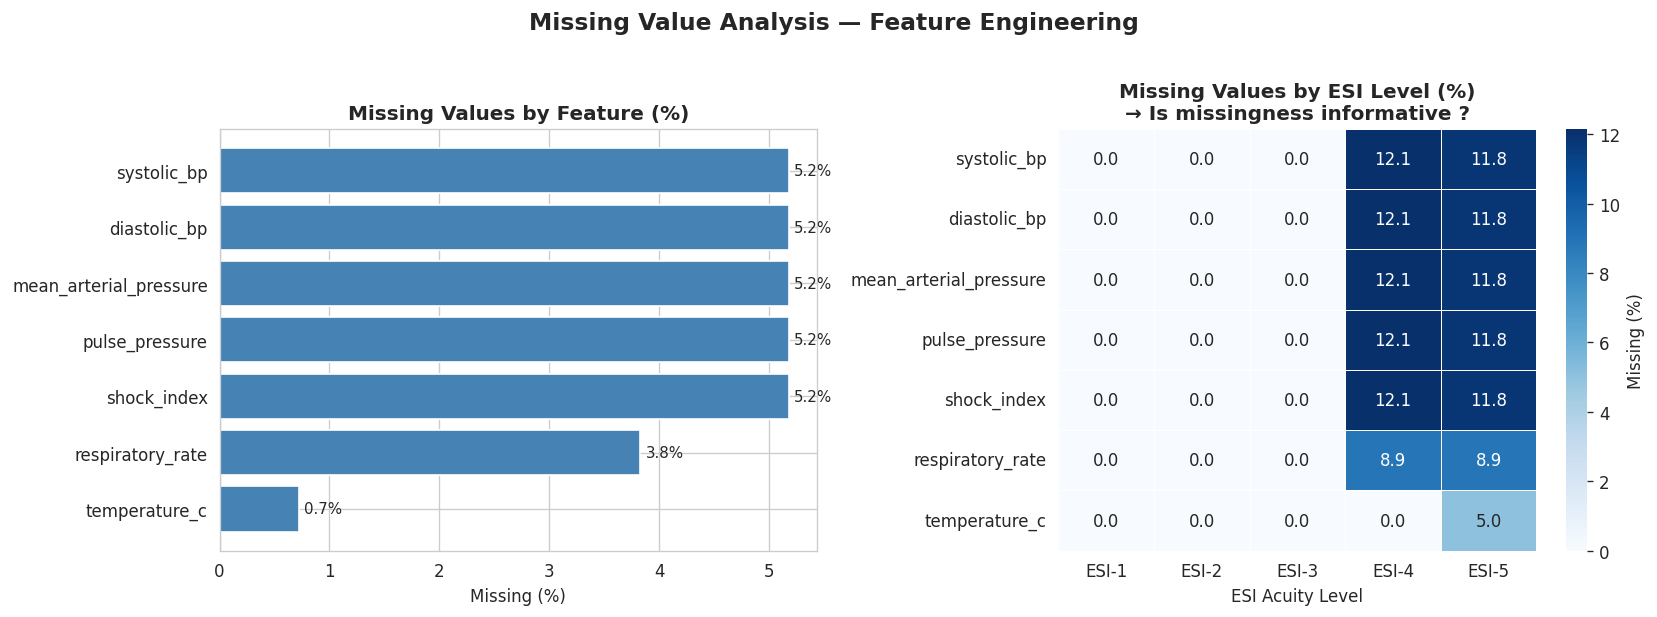


MISSING BY ESI LEVEL
                        ESI-1  ESI-2  ESI-3  ESI-4  ESI-5
systolic_bp               0.0    0.0    0.0   12.1   11.8
diastolic_bp              0.0    0.0    0.0   12.1   11.8
mean_arterial_pressure    0.0    0.0    0.0   12.1   11.8
pulse_pressure            0.0    0.0    0.0   12.1   11.8
shock_index               0.0    0.0    0.0   12.1   11.8
respiratory_rate          0.0    0.0    0.0    8.9    8.9
temperature_c             0.0    0.0    0.0    0.0    5.0


In [18]:
# ============================================================
# C.2 — Missingness Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Barplot missing % ---
axes[0].barh(
    miss_pct.index[::-1],
    miss_pct.values[::-1],
    color='steelblue', edgecolor='white'
)
axes[0].set_title('Missing Values by Feature (%)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Missing (%)')
for i, v in enumerate(miss_pct.values[::-1]):
    axes[0].text(v + 0.05, i, f'{v:.1f}%',
                va='center', fontsize=9)

# --- Missing % par ESI ---
miss_by_esi = {}
for feat in miss.index:
    miss_by_esi[feat] = (
        train_clean.groupby('triage_acuity')[feat]
        .apply(lambda x: x.isnull().mean() * 100)
    )

miss_esi_df = pd.DataFrame(miss_by_esi)
miss_esi_df.index = [f'ESI-{i}' for i in miss_esi_df.index]

sns.heatmap(
    miss_esi_df.T,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    ax=axes[1],
    cbar_kws={'label': 'Missing (%)'}
)
axes[1].set_title('Missing Values by ESI Level (%)\n'
                   '→ Is missingness informative ?',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('ESI Acuity Level')

plt.suptitle('Missing Value Analysis — Feature Engineering',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print()
print("=" * 60)
print("MISSING BY ESI LEVEL")
print("=" * 60)
print(miss_esi_df.T.round(1).to_string())

### C.3 — Clinical Interpretation

In [19]:
# ============================================================
# C.3 — Clinical Interpretation of Missingness
# ============================================================

print("=" * 65)
print("CLINICAL INTERPRETATION OF MISSINGNESS")
print("=" * 65)

interpretations = {
    'systolic_bp' : {
        'clinical_meaning' : 'Blood pressure not measured',
        'hypothesis'       : 'More often missing in low-acuity patients',
        'implication'      : 'Missingness may indicate lower severity',
        'strategy'         : 'Keep missing indicator + impute with median'
    },
    'diastolic_bp': {
        'clinical_meaning' : 'Diastolic BP not measured',
        'hypothesis'       : 'Always missing when systolic_bp is missing',
        'implication'      : 'Same pattern as systolic_bp',
        'strategy'         : 'Keep missing indicator + impute with median'
    },
    'mean_arterial_pressure': {
        'clinical_meaning' : 'MAP derived from BP — missing when BP missing',
        'hypothesis'       : 'Correlated with systolic/diastolic missingness',
        'implication'      : 'Same pattern as BP',
        'strategy'         : 'Keep missing indicator + impute with median'
    },
    'pulse_pressure': {
        'clinical_meaning' : 'Derived from BP — missing when BP missing',
        'hypothesis'       : 'Correlated with BP missingness',
        'implication'      : 'Same pattern as BP',
        'strategy'         : 'Keep missing indicator + impute with median'
    },
    'shock_index'  : {
        'clinical_meaning' : 'HR/SBP — missing when BP or HR missing',
        'hypothesis'       : 'Correlated with BP missingness',
        'implication'      : 'Same pattern as BP',
        'strategy'         : 'Keep missing indicator + impute with median'
    },
    'respiratory_rate': {
        'clinical_meaning' : 'RR not measured at triage',
        'hypothesis'       : 'Often skipped for low-acuity patients',
        'implication'      : 'Missingness = lower acuity signal',
        'strategy'         : 'Keep missing indicator + impute with median'
    },
    'temperature_c': {
        'clinical_meaning' : 'Temperature not taken immediately',
        'hypothesis'       : 'Less critical patients measured later',
        'implication'      : 'Weak signal but informative',
        'strategy'         : 'Keep missing indicator + impute with median'
    }
}

for feat, info in interpretations.items():
    if feat in miss.index:
        print(f"\n  📋 {feat}")
        for key, val in info.items():
            print(f"     {key:<22} : {val}")

print()
print("=" * 65)
print("KEY FINDING")
print("=" * 65)
print("""
  Missing vital signs may not be completely random.
  The distribution across ESI levels suggests that
  missingness itself may contain clinical information.

  This means :
  → Missingness itself carries clinical information
  → Missing indicators must be retained as features
  → Simple deletion would lose this information
""")

CLINICAL INTERPRETATION OF MISSINGNESS

  📋 systolic_bp
     clinical_meaning       : Blood pressure not measured
     hypothesis             : More often missing in low-acuity patients
     implication            : Missingness may indicate lower severity
     strategy               : Keep missing indicator + impute with median

  📋 diastolic_bp
     clinical_meaning       : Diastolic BP not measured
     hypothesis             : Always missing when systolic_bp is missing
     implication            : Same pattern as systolic_bp
     strategy               : Keep missing indicator + impute with median

  📋 mean_arterial_pressure
     clinical_meaning       : MAP derived from BP — missing when BP missing
     hypothesis             : Correlated with systolic/diastolic missingness
     implication            : Same pattern as BP
     strategy               : Keep missing indicator + impute with median

  📋 pulse_pressure
     clinical_meaning       : Derived from BP — missing when BP mis

### C.4 — Missing Indicators

In [20]:
# ============================================================
# C.4 — Create Missing Indicators
# ============================================================

# Variables pour lesquelles créer un indicateur
indicator_vars = [
    'systolic_bp',
    'diastolic_bp',
    'mean_arterial_pressure',
    'pulse_pressure',
    'shock_index',
    'respiratory_rate',
    'temperature_c'
]

print("=" * 55)
print("CREATING MISSING INDICATORS")
print("=" * 55)

created_indicators = []

for var in indicator_vars:
    if var in train_clean.columns:
        # Train
        indicator_name = f'{var}_missing'
        train_clean[indicator_name] = (
            train_clean[var].isnull().astype(int)
        )
        # Test
        if var in test_clean.columns:
            test_clean[indicator_name] = (
                test_clean[var].isnull().astype(int)
            )
        created_indicators.append(indicator_name)
        n_missing = train_clean[indicator_name].sum()
        print(f"  ✅ {indicator_name:<35} : "
              f"{n_missing:,} flagged "
              f"({n_missing/len(train_clean)*100:.1f}%)")

print()

# Traitement spécial pain_score
train_clean['pain_not_recorded'] = (
    train_clean['pain_score'] == -1).astype(int)
test_clean['pain_not_recorded'] = (
    test_clean['pain_score'] == -1).astype(int)
created_indicators.append('pain_not_recorded')

n_pain = train_clean['pain_not_recorded'].sum()
print(f"  ✅ {'pain_not_recorded':<35} : "
      f"{n_pain:,} flagged "
      f"({n_pain/len(train_clean)*100:.1f}%)")

# Remplacer -1 par NaN pour pain_score
train_clean.loc[
    train_clean['pain_score'] == -1, 'pain_score'] = np.nan
test_clean.loc[
    test_clean['pain_score'] == -1, 'pain_score'] = np.nan

print()
print(f"  Total indicators created : {len(created_indicators)}")
print(f"  pain_score : -1 → NaN ✅")

CREATING MISSING INDICATORS
  ✅ systolic_bp_missing                 : 4,146 flagged (5.2%)
  ✅ diastolic_bp_missing                : 4,146 flagged (5.2%)
  ✅ mean_arterial_pressure_missing      : 4,146 flagged (5.2%)
  ✅ pulse_pressure_missing              : 4,146 flagged (5.2%)
  ✅ shock_index_missing                 : 4,146 flagged (5.2%)
  ✅ respiratory_rate_missing            : 3,067 flagged (3.8%)
  ✅ temperature_c_missing               : 574 flagged (0.7%)

  ✅ pain_not_recorded                   : 11,156 flagged (13.9%)

  Total indicators created : 8
  pain_score : -1 → NaN ✅


### C.5 — Imputation Strategy Table

In [21]:
# ============================================================
# C.5 — Imputation Strategy Table
# ============================================================

strategy_table = pd.DataFrame([
    {
        'Feature'         : 'systolic_bp',
        'Type'            : 'Numeric',
        'Missing %'       : f"{miss_pct.get('systolic_bp', 0):.1f}%",
        'Strategy'        : 'Median by age_group',
        'Reason'          : 'Age-aware imputation'
    },
    {
        'Feature'         : 'diastolic_bp',
        'Type'            : 'Numeric',
        'Missing %'       : f"{miss_pct.get('diastolic_bp', 0):.1f}%",
        'Strategy'        : 'Median by age_group',
        'Reason'          : 'Age-aware imputation'
    },
    {
        'Feature'         : 'mean_arterial_pressure',
        'Type'            : 'Numeric',
        'Missing %'       : f"{miss_pct.get('mean_arterial_pressure', 0):.1f}%",
        'Strategy'        : 'Median by age_group',
        'Reason'          : 'Derived from BP'
    },
    {
        'Feature'         : 'pulse_pressure',
        'Type'            : 'Numeric',
        'Missing %'       : f"{miss_pct.get('pulse_pressure', 0):.1f}%",
        'Strategy'        : 'Median by age_group',
        'Reason'          : 'Derived from BP'
    },
    {
        'Feature'         : 'shock_index',
        'Type'            : 'Numeric',
        'Missing %'       : f"{miss_pct.get('shock_index', 0):.1f}%",
        'Strategy'        : 'Median by age_group',
        'Reason'          : 'Derived from HR/SBP'
    },
    {
        'Feature'         : 'respiratory_rate',
        'Type'            : 'Numeric',
        'Missing %'       : f"{miss_pct.get('respiratory_rate', 0):.1f}%",
        'Strategy'        : 'Median by age_group',
        'Reason'          : 'Age-specific normal values'
    },
    {
        'Feature'         : 'temperature_c',
        'Type'            : 'Numeric',
        'Missing %'       : f"{miss_pct.get('temperature_c', 0):.1f}%",
        'Strategy'        : 'Median global',
        'Reason'          : 'Less variable across ages'
    },
    {
        'Feature'         : 'pain_score',
        'Type'            : 'Numeric',
        'Missing %'       : 'See pain_not_recorded',
        'Strategy'        : 'Median by age_group',
        'Reason'          : '-1 already handled'
    },
    {
        'Feature'         : 'language',
        'Type'            : 'Categorical',
        'Missing %'       : '0%',
        'Strategy'        : 'Most frequent',
        'Reason'          : 'If any NA found'
    },
    {
        'Feature'         : 'insurance_type',
        'Type'            : 'Categorical',
        'Missing %'       : '0%',
        'Strategy'        : 'Most frequent',
        'Reason'          : 'If any NA found'
    }
])

print("=" * 80)
print("IMPUTATION STRATEGY TABLE")
print("=" * 80)
print(strategy_table.to_string(index=False))

IMPUTATION STRATEGY TABLE
               Feature        Type             Missing %            Strategy                     Reason
           systolic_bp     Numeric                  5.2% Median by age_group       Age-aware imputation
          diastolic_bp     Numeric                  5.2% Median by age_group       Age-aware imputation
mean_arterial_pressure     Numeric                  5.2% Median by age_group            Derived from BP
        pulse_pressure     Numeric                  5.2% Median by age_group            Derived from BP
           shock_index     Numeric                  5.2% Median by age_group        Derived from HR/SBP
      respiratory_rate     Numeric                  3.8% Median by age_group Age-specific normal values
         temperature_c     Numeric                  0.7%       Median global  Less variable across ages
            pain_score     Numeric See pain_not_recorded Median by age_group         -1 already handled
              language Categorical    

### C.6 — Age-Aware Imputation

In [22]:
# ============================================================
# C.6 — Apply Age-Aware Imputation
# ============================================================

numeric_to_impute = [
    'systolic_bp',
    'diastolic_bp',
    'respiratory_rate',
    'temperature_c',
    'pain_score'
]

print("=" * 60)
print("APPLYING AGE-AWARE IMPUTATION")
print("=" * 60)
print("Strategy : Median by age_group")
print("Fallback : Global median if group median unavailable")
print()

for col in numeric_to_impute:
    if col not in train_clean.columns:
        continue

    missing_before_train = train_clean[col].isnull().sum()
    missing_before_test  = test_clean[col].isnull().sum() \
                           if col in test_clean.columns else 0

    # Calculer médianes par age_group sur train
    group_medians = train_clean.groupby(
        'age_group')[col].median()
    global_median = train_clean[col].median()

    # Imputer train
    for group in train_clean['age_group'].unique():
        mask = (train_clean['age_group'] == group) & \
               (train_clean[col].isnull())
        median_val = group_medians.get(group, global_median)
        train_clean.loc[mask, col] = median_val

    # Fallback global pour train
    train_clean[col] = train_clean[col].fillna(global_median)

    # Imputer test
    if col in test_clean.columns:
        for group in test_clean['age_group'].unique():
            mask = (test_clean['age_group'] == group) & \
                   (test_clean[col].isnull())
            median_val = group_medians.get(group, global_median)
            test_clean.loc[mask, col] = median_val
        test_clean[col] = test_clean[col].fillna(global_median)

    missing_after = train_clean[col].isnull().sum()
    print(f"  {col:<30} : "
          f"before={missing_before_train:>5,}  "
          f"after={missing_after:>3}  "
          f"{'✅' if missing_after == 0 else '⚠️'}")

# Imputation catégorielle
cat_to_impute = ['language', 'insurance_type']
print()
for col in cat_to_impute:
    if col in train_clean.columns:
        most_freq = train_clean[col].mode()[0]
        train_clean[col] = train_clean[col].fillna(most_freq)
        if col in test_clean.columns:
            test_clean[col] = test_clean[col].fillna(most_freq)
        print(f"  {col:<30} : filled with '{most_freq}' ✅")

APPLYING AGE-AWARE IMPUTATION
Strategy : Median by age_group
Fallback : Global median if group median unavailable

  systolic_bp                    : before=4,146  after=  0  ✅
  diastolic_bp                   : before=4,146  after=  0  ✅
  respiratory_rate               : before=3,067  after=  0  ✅
  temperature_c                  : before=  574  after=  0  ✅
  pain_score                     : before=11,156  after=  0  ✅

  language                       : filled with 'Finnish' ✅
  insurance_type                 : filled with 'public' ✅


### C.7 — Verification

In [23]:
# ============================================================
# C.7 — Post-Imputation Verification
# ============================================================

# Exclure texte et target
exclude = [
    'chief_complaint_raw',
    'chief_complaint_system',
    'triage_acuity'
]

train_check = train_clean.drop(
    columns=[c for c in exclude if c in train_clean.columns]
)

test_check = test_clean.drop(
    columns=[c for c in exclude if c in test_clean.columns]
)

remaining_train = train_check.isnull().sum().sum()
remaining_test  = test_check.isnull().sum().sum()

print("=" * 60)
print("POST-IMPUTATION VERIFICATION")
print("=" * 60)

print("\nTRAIN")
print(f"  Missing before imputation : {miss.sum():,}")
print(f"  Missing after imputation  : {remaining_train:,}")
print(f"  Status : {'✅ Complete' if remaining_train == 0 else '⚠️ Still missing'}")

print("\nTEST")
print(f"  Missing after imputation  : {remaining_test:,}")
print(f"  Status : {'✅ Complete' if remaining_test == 0 else '⚠️ Still missing'}")

remaining_cols = []

if remaining_train > 0:

    print("\nRemaining missing values (train) :")

    remaining = train_check.isnull().sum()
    remaining = remaining[remaining > 0]

    for col, n in remaining.items():
        print(f"  ⚠️ {col:<30} : {n:,}")
        remaining_cols.append(col)

print()

print("=" * 60)
print("PART C SUMMARY")
print("=" * 60)

if remaining_train == 0:

    print(f"""
  ✅ Missing value audit completed
  ✅ Clinical interpretation documented
  ✅ Missing indicators created : {len(created_indicators)}
  ✅ Age-aware imputation applied
  ✅ pain_score : -1 → NaN → imputed
  ✅ No remaining missing values

  train_clean : {train_clean.shape[0]:,} x {train_clean.shape[1]}
  test_clean  : {test_clean.shape[0]:,} x {test_clean.shape[1]}

  Ready for Part D : Clinical Feature Engineering
""")

else:

    print(f"""
  ✅ Missing value audit completed
  ✅ Clinical interpretation documented
  ✅ Missing indicators created : {len(created_indicators)}
  ✅ Age-aware imputation applied
  ✅ pain_score : -1 → NaN → imputed

  ⚠️ Remaining missing values persist in:
     {", ".join(remaining_cols)}

  Clinical rationale:
  These variables are derived measurements and will be
  recomputed during Part D (Clinical Feature Engineering)
  using imputed systolic_bp,
  diastolic_bp and heart_rate values

  train_clean : {train_clean.shape[0]:,} x {train_clean.shape[1]}
  test_clean  : {test_clean.shape[0]:,} x {test_clean.shape[1]}

  Ready for Part D : Clinical Feature Engineering
""")

POST-IMPUTATION VERIFICATION

TRAIN
  Missing before imputation : 24,371
  Missing after imputation  : 12,438
  Status : ⚠️ Still missing

TEST
  Missing after imputation  : 2,886
  Status : ⚠️ Still missing

Remaining missing values (train) :
  ⚠️ mean_arterial_pressure         : 4,146
  ⚠️ pulse_pressure                 : 4,146
  ⚠️ shock_index                    : 4,146

PART C SUMMARY

  ✅ Missing value audit completed
  ✅ Clinical interpretation documented
  ✅ Missing indicators created : 8
  ✅ Age-aware imputation applied
  ✅ pain_score : -1 → NaN → imputed

  ⚠️ Remaining missing values persist in:
     mean_arterial_pressure, pulse_pressure, shock_index

  Clinical rationale:
  These variables are derived measurements and will be
  recomputed during Part D (Clinical Feature Engineering)
  using imputed systolic_bp,
  diastolic_bp and heart_rate values

  train_clean : 80,000 x 44
  test_clean  : 20,000 x 43

  Ready for Part D : Clinical Feature Engineering



## D — Clinical Feature Engineering

### D.1 — Recompute Derived Variables

In [24]:
# ============================================================
# PART D — CLINICAL FEATURE ENGINEERING
# D.1 — Recompute Derived Variables
# ============================================================

print("=" * 60)
print("D.1 — RECOMPUTING DERIVED VARIABLES")
print("=" * 60)
print("Reason : Recalculated > Imputed (scientifically)")
print()

# Copier train_clean et test_clean
train_fe = train_clean.copy()
test_fe  = test_clean.copy()

# --- Mean Arterial Pressure ---
# MAP = DBP + (1/3) * (SBP - DBP)
train_fe['mean_arterial_pressure'] = (
    train_fe['diastolic_bp'] +
    (1/3) * (train_fe['systolic_bp'] - train_fe['diastolic_bp'])
)
test_fe['mean_arterial_pressure'] = (
    test_fe['diastolic_bp'] +
    (1/3) * (test_fe['systolic_bp'] - test_fe['diastolic_bp'])
)

# --- Pulse Pressure ---
# PP = SBP - DBP
train_fe['pulse_pressure'] = (
    train_fe['systolic_bp'] - train_fe['diastolic_bp']
)
test_fe['pulse_pressure'] = (
    test_fe['systolic_bp'] - test_fe['diastolic_bp']
)

# --- Shock Index ---
# SI = HR / SBP
train_fe['shock_index'] = (
    train_fe['heart_rate'] / train_fe['systolic_bp']
)
test_fe['shock_index'] = (
    test_fe['heart_rate'] / test_fe['systolic_bp']
)

# Vérification
vars_recomputed = [
    'mean_arterial_pressure',
    'pulse_pressure',
    'shock_index'
]

for var in vars_recomputed:
    na_train = train_fe[var].isnull().sum()
    na_test  = test_fe[var].isnull().sum()
    print(f"  {var:<30} : "
          f"train NA={na_train}  "
          f"test NA={na_test}  "
          f"{'✅' if na_train == 0 else '⚠️'}")

D.1 — RECOMPUTING DERIVED VARIABLES
Reason : Recalculated > Imputed (scientifically)

  mean_arterial_pressure         : train NA=0  test NA=0  ✅
  pulse_pressure                 : train NA=0  test NA=0  ✅
  shock_index                    : train NA=0  test NA=0  ✅


### D.2 — Clinical Risk Flags

In [25]:
# ============================================================
# D.2 — Create Clinical Risk Flags
# ============================================================

print("=" * 60)
print("D.2 — CREATING CLINICAL RISK FLAGS")
print("=" * 60)
print()

# Définir les flags et leurs seuils
clinical_flags = {
    'hypoxemia_flag'   : {
        'condition' : lambda df: df['spo2'] < 90,
        'threshold' : 'SpO2 < 90%',
        'rationale' : 'Significant hypoxemia threshold'
    },
    'tachycardia_flag' : {
        'condition' : lambda df: df['heart_rate'] > 100,
        'threshold' : 'HR > 100 bpm',
        'rationale' : 'Standard tachycardia definition'
    },
    'hypotension_flag' : {
        'condition' : lambda df: df['systolic_bp'] < 90,
        'threshold' : 'SBP < 90 mmHg',
        'rationale' : 'Hypotension / shock threshold'
    },
    'fever_flag'       : {
        'condition' : lambda df: df['temperature_c'] >= 38.0,
        'threshold' : 'Temp >= 38.0°C',
        'rationale' : 'Standard fever definition'
    },
    'altered_gcs_flag' : {
        'condition' : lambda df: df['gcs_total'] < 15,
        'threshold' : 'GCS < 15',
        'rationale' : 'Any alteration of consciousness'
    },
    'severe_pain_flag' : {
        'condition' : lambda df: df['pain_score'] >= 7,
        'threshold' : 'Pain >= 7/10',
        'rationale' : 'Severe pain threshold'
    }
}

# Créer les flags
for flag_name, info in clinical_flags.items():
    train_fe[flag_name] = (
        info['condition'](train_fe)
        .astype(int)
    )
    test_fe[flag_name] = (
        info['condition'](test_fe)
        .astype(int)
    )

    n_flagged     = train_fe[flag_name].sum()
    pct_flagged   = n_flagged / len(train_fe) * 100

    # Corrélation avec acuité
    corr = train_fe[flag_name].corr(
        train_fe['triage_acuity'])

    print(f"  ✅ {flag_name:<25} : "
          f"threshold={info['threshold']:<20} "
          f"flagged={pct_flagged:>5.1f}%  "
          f"corr={corr:>+.3f}")

D.2 — CREATING CLINICAL RISK FLAGS

  ✅ hypoxemia_flag            : threshold=SpO2 < 90%           flagged=  9.4%  corr=-0.479
  ✅ tachycardia_flag          : threshold=HR > 100 bpm         flagged= 29.9%  corr=-0.491
  ✅ hypotension_flag          : threshold=SBP < 90 mmHg        flagged=  9.9%  corr=-0.422
  ✅ fever_flag                : threshold=Temp >= 38.0°C       flagged= 31.1%  corr=-0.577
  ✅ altered_gcs_flag          : threshold=GCS < 15             flagged= 18.4%  corr=-0.705
  ✅ severe_pain_flag          : threshold=Pain >= 7/10         flagged= 32.2%  corr=-0.559


### D.3 — Critical Vital Count

In [26]:
# ============================================================
# D.3 — Critical Vital Count
# ============================================================

# Additionner les flags vitaux
vital_flags = [
    'hypoxemia_flag',
    'tachycardia_flag',
    'hypotension_flag',
    'fever_flag',
    'altered_gcs_flag'
]

train_fe['critical_vital_count'] = (
    train_fe[vital_flags].sum(axis=1)
)
test_fe['critical_vital_count'] = (
    test_fe[vital_flags].sum(axis=1)
)

print("=" * 60)
print("D.3 — CRITICAL VITAL COUNT")
print("=" * 60)
print("Formula : sum of hypoxemia + tachycardia + "
      "hypotension + fever + altered_gcs")
print()

# Distribution par ESI
count_by_esi = train_fe.groupby(
    'triage_acuity')['critical_vital_count'].median()

print(f"  {'ESI Level':<15} {'Median Count':>12}")
print("-" * 30)
for esi, val in count_by_esi.items():
    bar = '█' * int(val * 3)
    print(f"  ESI-{esi:<10} {val:>12.1f}  {bar}")

print()

# Distribution globale
dist = train_fe['critical_vital_count'].value_counts(
    ).sort_index()
print(f"  Distribution of critical_vital_count :")
for count, n in dist.items():
    pct = n / len(train_fe) * 100
    print(f"  {count} abnormal vitals : "
          f"{n:>7,} patients ({pct:.1f}%)")

# Corrélation
corr = train_fe['critical_vital_count'].corr(
    train_fe['triage_acuity'])
print(f"\n  Correlation with triage_acuity : {corr:+.3f}")

D.3 — CRITICAL VITAL COUNT
Formula : sum of hypoxemia + tachycardia + hypotension + fever + altered_gcs

  ESI Level       Median Count
------------------------------
  ESI-1                   4.0  ████████████
  ESI-2                   3.0  █████████
  ESI-3                   1.0  ███
  ESI-4                   0.0  
  ESI-5                   0.0  

  Distribution of critical_vital_count :
  0 abnormal vitals :  41,584 patients (52.0%)
  1 abnormal vitals :  18,137 patients (22.7%)
  2 abnormal vitals :   7,886 patients (9.9%)
  3 abnormal vitals :   6,155 patients (7.7%)
  4 abnormal vitals :   4,621 patients (5.8%)
  5 abnormal vitals :   1,617 patients (2.0%)

  Correlation with triage_acuity : -0.775


D.4 — Age Clinical Features

In [27]:
# ============================================================
# D.4 — Age Clinical Features
# ============================================================

print("=" * 55)
print("D.4 — AGE CLINICAL FEATURES")
print("=" * 55)
print()

# Elderly
train_fe['elderly'] = (train_fe['age'] >= 65).astype(int)
test_fe['elderly']  = (test_fe['age'] >= 65).astype(int)

n_elderly     = train_fe['elderly'].sum()
pct_elderly   = n_elderly / len(train_fe) * 100
corr_elderly  = train_fe['elderly'].corr(
    train_fe['triage_acuity'])

print(f"  ✅ elderly (age >= 65)     : "
      f"{n_elderly:,} patients ({pct_elderly:.1f}%)  "
      f"corr={corr_elderly:+.3f}")

# Very elderly
train_fe['very_elderly'] = (train_fe['age'] >= 80).astype(int)
test_fe['very_elderly']  = (test_fe['age'] >= 80).astype(int)

n_very        = train_fe['very_elderly'].sum()
pct_very      = n_very / len(train_fe) * 100
corr_very     = train_fe['very_elderly'].corr(
    train_fe['triage_acuity'])

print(f"  ✅ very_elderly (age >= 80): "
      f"{n_very:,} patients ({pct_very:.1f}%)  "
      f"corr={corr_very:+.3f}")

# Pediatric
train_fe['pediatric'] = (train_fe['age'] < 16).astype(int)
test_fe['pediatric']  = (test_fe['age'] < 16).astype(int)

n_ped         = train_fe['pediatric'].sum()
pct_ped       = n_ped / len(train_fe) * 100
corr_ped      = train_fe['pediatric'].corr(
    train_fe['triage_acuity'])

print(f"  ✅ pediatric (age < 16)    : "
      f"{n_ped:,} patients ({pct_ped:.1f}%)  "
      f"corr={corr_ped:+.3f}")

D.4 — AGE CLINICAL FEATURES

  ✅ elderly (age >= 65)     : 21,653 patients (27.1%)  corr=-0.002
  ✅ very_elderly (age >= 80): 10,861 patients (13.6%)  corr=-0.003
  ✅ pediatric (age < 16)    : 6,595 patients (8.2%)  corr=+0.000


### D.5 — Comorbidity Burden Features

In [28]:
# ============================================================
# D.5 — Comorbidity Burden Features
# ============================================================

# Quick check before starting
print("Pre-check :")
print(f"  num_comorbidities in train_fe      : "
      f"{'✅' if 'num_comorbidities' in train_fe.columns else '❌'}")
print(f"  num_active_medications in train_fe : "
      f"{'✅' if 'num_active_medications' in train_fe.columns else '❌'}")
print(f"  bmi in train_fe                    : "
      f"{'✅' if 'bmi' in train_fe.columns else '❌'}")
print()

print("=" * 55)
print("D.5 — COMORBIDITY BURDEN FEATURES")
print("=" * 55)
print()

# High Comorbidity Burden
train_fe['high_comorbidity'] = (
    train_fe['num_comorbidities'] >= 5).astype(int)
test_fe['high_comorbidity'] = (
    test_fe['num_comorbidities'] >= 5).astype(int)

n_hc    = train_fe['high_comorbidity'].sum()
pct_hc  = n_hc / len(train_fe) * 100
corr_hc = train_fe['high_comorbidity'].corr(
    train_fe['triage_acuity'])

print(f"  ✅ high_comorbidity (>= 5) : "
      f"{n_hc:,} patients ({pct_hc:.1f}%)  "
      f"corr={corr_hc:+.3f}")

# Polypharmacy
train_fe['polypharmacy'] = (
    train_fe['num_active_medications'] >= 5).astype(int)
test_fe['polypharmacy'] = (
    test_fe['num_active_medications'] >= 5).astype(int)

n_pp    = train_fe['polypharmacy'].sum()
pct_pp  = n_pp / len(train_fe) * 100
corr_pp = train_fe['polypharmacy'].corr(
    train_fe['triage_acuity'])

print(f"  ✅ polypharmacy (>= 5 meds): "
      f"{n_pp:,} patients ({pct_pp:.1f}%)  "
      f"corr={corr_pp:+.3f}")

# Obesity
if 'bmi' in train_fe.columns:
    train_fe['obesity'] = (
        train_fe['bmi'] >= 30).astype(int)
    test_fe['obesity'] = (
        test_fe['bmi'] >= 30).astype(int)

    n_ob    = train_fe['obesity'].sum()
    pct_ob  = n_ob / len(train_fe) * 100
    corr_ob = train_fe['obesity'].corr(
        train_fe['triage_acuity'])

    print(f"  ✅ obesity (BMI >= 30)     : "
          f"{n_ob:,} patients ({pct_ob:.1f}%)  "
          f"corr={corr_ob:+.3f}")
else:
    print(f"  ⚠️ bmi not found — obesity flag skipped")

print()
print("=" * 55)
print("D.5 COMPLETE")
print("=" * 55)
print(f"  train_fe shape : {train_fe.shape}")
print(f"  test_fe shape  : {test_fe.shape}")

Pre-check :
  num_comorbidities in train_fe      : ✅
  num_active_medications in train_fe : ✅
  bmi in train_fe                    : ✅

D.5 — COMORBIDITY BURDEN FEATURES

  ✅ high_comorbidity (>= 5) : 43,473 patients (54.3%)  corr=-0.118
  ✅ polypharmacy (>= 5 meds): 35,350 patients (44.2%)  corr=-0.080
  ✅ obesity (BMI >= 30)     : 23,455 patients (29.3%)  corr=+0.000

D.5 COMPLETE
  train_fe shape : (80000, 57)
  test_fe shape  : (20000, 56)


### D.6 — Utilization Risk Features

In [29]:
# ============================================================
# D.6 — Utilization Risk Features
# ============================================================

print("=" * 60)
print("D.6 — UTILIZATION RISK FEATURES")
print("=" * 60)
print()

# Frequent ED User
train_fe['frequent_ed_user'] = (
    train_fe['num_prior_ed_visits_12m'] >= 3).astype(int)
test_fe['frequent_ed_user'] = (
    test_fe['num_prior_ed_visits_12m'] >= 3).astype(int)

n_freq    = train_fe['frequent_ed_user'].sum()
pct_freq  = n_freq / len(train_fe) * 100
corr_freq = train_fe['frequent_ed_user'].corr(
    train_fe['triage_acuity'])

print(f"  ✅ frequent_ed_user (>= 3 visits) : "
      f"{n_freq:,} patients ({pct_freq:.1f}%)  "
      f"corr={corr_freq:+.3f}")

# Prior Admission Flag
train_fe['prior_admission_flag'] = (
    train_fe['num_prior_admissions_12m'] > 0).astype(int)
test_fe['prior_admission_flag'] = (
    test_fe['num_prior_admissions_12m'] > 0).astype(int)

n_adm    = train_fe['prior_admission_flag'].sum()
pct_adm  = n_adm / len(train_fe) * 100
corr_adm = train_fe['prior_admission_flag'].corr(
    train_fe['triage_acuity'])

print(f"  ✅ prior_admission_flag (> 0)     : "
      f"{n_adm:,} patients ({pct_adm:.1f}%)  "
      f"corr={corr_adm:+.3f}")

# High Utilization
train_fe['high_utilization'] = (
    (train_fe['frequent_ed_user'] == 1) |
    (train_fe['prior_admission_flag'] == 1)
).astype(int)
test_fe['high_utilization'] = (
    (test_fe['frequent_ed_user'] == 1) |
    (test_fe['prior_admission_flag'] == 1)
).astype(int)

n_hu    = train_fe['high_utilization'].sum()
pct_hu  = n_hu / len(train_fe) * 100
corr_hu = train_fe['high_utilization'].corr(
    train_fe['triage_acuity'])

print(f"  ✅ high_utilization (ED or admit) : "
      f"{n_hu:,} patients ({pct_hu:.1f}%)  "
      f"corr={corr_hu:+.3f}")

D.6 — UTILIZATION RISK FEATURES

  ✅ frequent_ed_user (>= 3 visits) : 14,992 patients (18.7%)  corr=-0.442
  ✅ prior_admission_flag (> 0)     : 22,933 patients (28.7%)  corr=-0.312
  ✅ high_utilization (ED or admit) : 27,937 patients (34.9%)  corr=-0.408


### D.7 — Feature Quality Check

In [30]:
# ============================================================
# D.7 — Feature Quality Check
# ============================================================

# Toutes les nouvelles features
new_features = [
    'mean_arterial_pressure', 'pulse_pressure', 'shock_index',
    'hypoxemia_flag', 'tachycardia_flag', 'hypotension_flag',
    'fever_flag', 'altered_gcs_flag', 'severe_pain_flag',
    'critical_vital_count',
    'elderly', 'very_elderly', 'pediatric',
    'high_comorbidity', 'polypharmacy', 'obesity',
    'frequent_ed_user', 'prior_admission_flag',
    'high_utilization'
]

print("=" * 65)
print("D.7 — FEATURE QUALITY CHECK")
print("=" * 65)
print()

all_ok = True
for feat in new_features:
    if feat not in train_fe.columns:
        print(f"  ❌ {feat:<30} : NOT FOUND")
        all_ok = False
        continue

    na_count = train_fe[feat].isnull().sum()
    n_unique = train_fe[feat].nunique()
    corr     = train_fe[feat].corr(
        train_fe['triage_acuity'])
    status   = "✅" if na_count == 0 else "⚠️"

    print(f"  {status} {feat:<30} : "
          f"NA={na_count:>3}  "
          f"unique={n_unique:>3}  "
          f"corr={corr:>+.3f}")
    if na_count > 0:
        all_ok = False

print()
print(f"  Total new features created : {len(new_features)}")
print(f"  All features valid         : "
      f"{'✅ Yes' if all_ok else '❌ Check above'}")

D.7 — FEATURE QUALITY CHECK

  ✅ mean_arterial_pressure         : NA=  0  unique=4311  corr=+0.548
  ✅ pulse_pressure                 : NA=  0  unique=4202  corr=+0.195
  ✅ shock_index                    : NA=  0  unique=70185  corr=-0.632
  ✅ hypoxemia_flag                 : NA=  0  unique=  2  corr=-0.479
  ✅ tachycardia_flag               : NA=  0  unique=  2  corr=-0.491
  ✅ hypotension_flag               : NA=  0  unique=  2  corr=-0.422
  ✅ fever_flag                     : NA=  0  unique=  2  corr=-0.577
  ✅ altered_gcs_flag               : NA=  0  unique=  2  corr=-0.705
  ✅ severe_pain_flag               : NA=  0  unique=  2  corr=-0.559
  ✅ critical_vital_count           : NA=  0  unique=  6  corr=-0.775
  ✅ elderly                        : NA=  0  unique=  2  corr=-0.002
  ✅ very_elderly                   : NA=  0  unique=  2  corr=-0.003
  ✅ pediatric                      : NA=  0  unique=  2  corr=+0.000
  ✅ high_comorbidity               : NA=  0  unique=  2  corr=-0.118
 

## E — Categorical Encoding

### E.1 — Categorical Audit

In [31]:
# ============================================================
# E.1 — Categorical Audit
# ============================================================

print("=" * 65)
print("E.1 — CATEGORICAL AUDIT")
print("=" * 65)
print()

# Identifier toutes les colonnes object restantes
cat_cols = train_fe.select_dtypes(
    include=['object']).columns.tolist()

# Exclure texte libre
exclude_text = ['chief_complaint_raw']
cat_cols = [c for c in cat_cols if c not in exclude_text]

print(f"  Total categorical features found : {len(cat_cols)}")
print()
print(f"  {'Feature':<35} {'Unique':>8} {'Top Category':<20} {'Top %':>8}")
print("-" * 75)

for col in cat_cols:
    n_unique    = train_fe[col].nunique()
    top_cat     = train_fe[col].value_counts().index[0]
    top_pct     = train_fe[col].value_counts(
        normalize=True).iloc[0] * 100
    print(f"  {col:<35} {n_unique:>8} "
          f"{str(top_cat):<20} {top_pct:>7.1f}%")

print()
print("  Note : chief_complaint_raw excluded (handled in Part F)")

E.1 — CATEGORICAL AUDIT

  Total categorical features found : 14

  Feature                               Unique Top Category            Top %
---------------------------------------------------------------------------
  site_id                                    5 SITE-TUR-01             20.3%
  triage_nurse_id                           50 NURSE-0012               2.1%
  arrival_mode                               6 walk-in                 48.1%
  arrival_day                                7 Monday                  14.4%
  arrival_season                             4 autumn                  25.1%
  shift                                      4 morning                 33.4%
  age_group                                  4 middle_aged             34.9%
  sex                                        3 F                       50.4%
  language                                   8 Finnish                 55.2%
  insurance_type                             5 public                  60.2%
  transport

### E.2 — Encoding Strategy Table

In [32]:
# ============================================================
# E.2 — Encoding Strategy Table
# ============================================================

strategy = pd.DataFrame([
    {
        'Feature'       : 'sex',
        'Unique Values' : train_fe['sex'].nunique(),
        'Strategy'      : 'Label Encoding',
        'Reason'        : 'Few categories, no false order risk'
    },
    {
        'Feature'       : 'age_group',
        'Unique Values' : train_fe['age_group'].nunique(),
        'Strategy'      : 'Label Encoding',
        'Reason'        : 'Natural order exists (pediatric→elderly)'
    },
    {
        'Feature'       : 'insurance_type',
        'Unique Values' : train_fe['insurance_type'].nunique(),
        'Strategy'      : 'Label Encoding',
        'Reason'        : 'Few categories'
    },
    {
        'Feature'       : 'transport_origin',
        'Unique Values' : train_fe['transport_origin'].nunique(),
        'Strategy'      : 'Label Encoding',
        'Reason'        : 'Few categories'
    },
    {
        'Feature'       : 'pain_location',
        'Unique Values' : train_fe['pain_location'].nunique(),
        'Strategy'      : 'Label Encoding',
        'Reason'        : 'Few categories'
    },
    {
        'Feature'       : 'mental_status_triage',
        'Unique Values' : train_fe['mental_status_triage'].nunique(),
        'Strategy'      : 'Label Encoding',
        'Reason'        : 'Natural severity order exists'
    },
    {
        'Feature'       : 'arrival_mode',
        'Unique Values' : train_fe['arrival_mode'].nunique(),
        'Strategy'      : 'Frequency Encoding',
        'Reason'        : 'Nominal — no natural order'
    },
    {
        'Feature'       : 'arrival_day',
        'Unique Values' : train_fe['arrival_day'].nunique(),
        'Strategy'      : 'Frequency Encoding',
        'Reason'        : 'Nominal — no natural order'
    },
    {
        'Feature'       : 'arrival_season',
        'Unique Values' : train_fe['arrival_season'].nunique(),
        'Strategy'      : 'Frequency Encoding',
        'Reason'        : 'Nominal — no natural order'
    },
    {
        'Feature'       : 'shift',
        'Unique Values' : train_fe['shift'].nunique(),
        'Strategy'      : 'Frequency Encoding',
        'Reason'        : 'Nominal — no natural order'
    },
    {
        'Feature'       : 'language',
        'Unique Values' : train_fe['language'].nunique(),
        'Strategy'      : 'Frequency Encoding',
        'Reason'        : 'Many categories → compact'
    },
    {
        'Feature'       : 'chief_complaint_system',
        'Unique Values' : train_fe['chief_complaint_system'].nunique()
                          if 'chief_complaint_system' in train_fe.columns
                          else 0,
        'Strategy'      : 'Frequency Encoding',
        'Reason'        : 'Many categories → compact'
    },
    {
        'Feature'       : 'site_id',
        'Unique Values' : train_fe['site_id'].nunique()
                          if 'site_id' in train_fe.columns
                          else 0,
        'Strategy'      : 'Frequency Encoding',
        'Reason'        : 'Site-level signal → compact'
    }
])

print("=" * 80)
print("E.2 — ENCODING STRATEGY TABLE")
print("=" * 80)
print(strategy.to_string(index=False))
print()
print("  IMPORTANT NOTE :")
print("  arrival_mode, arrival_day, arrival_season, shift")
print("  → Nominal variables → Frequency Encoding")
print("  → Label Encoding would introduce false order")
print("  → ambulance=0, walk-in=1 has no clinical meaning")
print()
print("  One-Hot Encoding avoided for all variables")
print("  Reason : LightGBM/XGBoost work better with")
print("           Label/Frequency encoding")

E.2 — ENCODING STRATEGY TABLE
               Feature  Unique Values           Strategy                                   Reason
                   sex              3     Label Encoding      Few categories, no false order risk
             age_group              4     Label Encoding Natural order exists (pediatric→elderly)
        insurance_type              5     Label Encoding                           Few categories
      transport_origin              7     Label Encoding                           Few categories
         pain_location              9     Label Encoding                           Few categories
  mental_status_triage              5     Label Encoding            Natural severity order exists
          arrival_mode              6 Frequency Encoding               Nominal — no natural order
           arrival_day              7 Frequency Encoding               Nominal — no natural order
        arrival_season              4 Frequency Encoding               Nominal — no natu

### E.3 — Label Encoding

In [33]:
# ============================================================
# E.3 — Label Encoding
# Only for ordinal or low-cardinality variables
# ============================================================

from sklearn.preprocessing import LabelEncoder

# ONLY truly ordinal or low-cardinality variables
label_cols = [
    'sex',
    'age_group',
    'insurance_type',
    'transport_origin',
    'pain_location',
    'mental_status_triage'
]

# Garder uniquement les colonnes présentes
label_cols = [c for c in label_cols
              if c in train_fe.columns]

print("=" * 60)
print("E.3 — LABEL ENCODING")
print("Applied to : ordinal / low-cardinality variables")
print("=" * 60)
print()

label_encoders = {}

for col in label_cols:
    le = LabelEncoder()

    combined = pd.concat([
        train_fe[col].astype(str),
        test_fe[col].astype(str)
    ]).fillna('unknown')

    le.fit(combined)

    train_fe[col] = le.transform(
        train_fe[col].astype(str).fillna('unknown'))
    test_fe[col]  = le.transform(
        test_fe[col].astype(str).fillna('unknown'))

    label_encoders[col] = le
    n_classes = len(le.classes_)

    print(f"  ✅ {col:<30} : "
          f"{n_classes} categories → "
          f"0 to {n_classes-1}")

E.3 — LABEL ENCODING
Applied to : ordinal / low-cardinality variables

  ✅ sex                            : 3 categories → 0 to 2
  ✅ age_group                      : 4 categories → 0 to 3
  ✅ insurance_type                 : 5 categories → 0 to 4
  ✅ transport_origin               : 7 categories → 0 to 6
  ✅ pain_location                  : 9 categories → 0 to 8
  ✅ mental_status_triage           : 5 categories → 0 to 4


### E.4 — Frequency Encoding

In [34]:
# ============================================================
# E.4 — Frequency Encoding
# Applied to : nominal + high-cardinality variables
# ============================================================

freq_cols = [
    'arrival_mode',     # nominal ← moved from Label
    'arrival_day',      # nominal ← moved from Label
    'arrival_season',   # nominal ← moved from Label
    'shift',            # nominal ← moved from Label
    'language',
    'chief_complaint_system',
    'site_id'
]

# Garder uniquement les colonnes présentes
freq_cols = [c for c in freq_cols
             if c in train_fe.columns]

print("=" * 65)
print("E.4 — FREQUENCY ENCODING")
print("Applied to : nominal + high-cardinality variables")
print("=" * 65)
print()

freq_maps = {}

for col in freq_cols:
    freq_map = (
        train_fe[col]
        .value_counts(normalize=True)
        .to_dict()
    )

    train_fe[col] = (
        train_fe[col]
        .map(freq_map)
        .fillna(0)
    )
    test_fe[col] = (
        test_fe[col]
        .map(freq_map)
        .fillna(0)
    )

    freq_maps[col] = freq_map
    n_cats = len(freq_map)

    print(f"  ✅ {col:<30} : "
          f"{n_cats} categories → frequency values")
    print(f"     Top 3 values :")
    for cat, freq in list(freq_map.items())[:3]:
        print(f"       {str(cat):<20} → {freq:.4f}")
    print()

E.4 — FREQUENCY ENCODING
Applied to : nominal + high-cardinality variables

  ✅ arrival_mode                   : 6 categories → frequency values
     Top 3 values :
       walk-in              → 0.4807
       ambulance            → 0.2801
       transfer             → 0.0998

  ✅ arrival_day                    : 7 categories → frequency values
     Top 3 values :
       Monday               → 0.1442
       Thursday             → 0.1442
       Saturday             → 0.1434

  ✅ arrival_season                 : 4 categories → frequency values
     Top 3 values :
       autumn               → 0.2507
       winter               → 0.2504
       spring               → 0.2502

  ✅ shift                          : 4 categories → frequency values
     Top 3 values :
       morning              → 0.3335
       night                → 0.2530
       afternoon            → 0.2495

  ✅ language                       : 8 categories → frequency values
     Top 3 values :
       Finnish              → 0

### E.5 — Verify Encodings

In [38]:
# ============================================================
# REMOVE TRIAGE NURSE ID (already identified as non-predictive)
# ============================================================

train_fe = train_fe.drop(
    columns=['triage_nurse_id'],
    errors='ignore'
)

test_fe = test_fe.drop(
    columns=['triage_nurse_id'],
    errors='ignore'
)

print("✅ triage_nurse_id removed")

✅ triage_nurse_id removed


In [39]:
train_fe.select_dtypes(include=['object']).columns.tolist()

[]

In [40]:
# ============================================================
# E.5 — Verify Encodings
# ============================================================

print("=" * 55)
print("E.5 — VERIFY ENCODINGS")
print("=" * 55)
print()

# Colonnes object restantes
# Exclure texte libre
exclude = ['chief_complaint_raw']

remaining_obj_train = [
    c for c in train_fe.select_dtypes(
        include=['object']).columns
    if c not in exclude
]
remaining_obj_test = [
    c for c in test_fe.select_dtypes(
        include=['object']).columns
    if c not in exclude
]

print(f"  Remaining object columns in train : "
      f"{len(remaining_obj_train)}")
print(f"  Remaining object columns in test  : "
      f"{len(remaining_obj_test)}")

if len(remaining_obj_train) == 0:
    print()
    print("  ✅ All categorical features encoded successfully")
else:
    print()
    print("  ⚠️ Still object columns :")
    for col in remaining_obj_train:
        print(f"    → {col} : "
              f"{train_fe[col].nunique()} unique values")

E.5 — VERIFY ENCODINGS

  Remaining object columns in train : 0
  Remaining object columns in test  : 0

  ✅ All categorical features encoded successfully


### E.6 — Encoding Quality Check

In [41]:
# ============================================================
# E.6 — Encoding Quality Check
# ============================================================

all_encoded = label_cols + freq_cols

print("=" * 65)
print("E.6 — ENCODING QUALITY CHECK")
print("=" * 65)
print()
print(f"  {'Feature':<35} {'Unique':>8} "
      f"{'NA':>6} {'Corr w/ Target':>15}")
print("-" * 70)

all_ok = True
for col in all_encoded:
    if col not in train_fe.columns:
        continue
    n_unique = train_fe[col].nunique()
    na_count = train_fe[col].isnull().sum()
    corr     = train_fe[col].corr(
        train_fe['triage_acuity'])
    status   = "✅" if na_count == 0 else "⚠️"
    if na_count > 0:
        all_ok = False
    print(f"  {status} {col:<33} {n_unique:>8} "
          f"{na_count:>6} {corr:>+15.3f}")

print()
print(f"  All features clean : "
      f"{'✅ Yes' if all_ok else '❌ Check above'}")

E.6 — ENCODING QUALITY CHECK

  Feature                               Unique     NA  Corr w/ Target
----------------------------------------------------------------------
  ✅ sex                                      3      0          +0.001
  ✅ age_group                                4      0          +0.003
  ✅ insurance_type                           5      0          +0.000
  ✅ transport_origin                         7      0          -0.008
  ✅ pain_location                            9      0          -0.002
  ✅ mental_status_triage                     5      0          -0.467
  ✅ arrival_mode                             6      0          -0.004
  ✅ arrival_day                              7      0          -0.007
  ✅ arrival_season                           4      0          +0.001
  ✅ shift                                    4      0          -0.003
  ✅ language                                 8      0          +0.003
  ✅ chief_complaint_system                  14      0      

### E.7 — Summary

In [37]:
# ============================================================
# E.7 — Categorical Encoding Summary
# ============================================================

# Colonnes object restantes
exclude   = ['chief_complaint_raw']
remaining = [
    c for c in train_fe.select_dtypes(
        include=['object']).columns
    if c not in exclude
]

print("=" * 65)
print("E.7 — CATEGORICAL ENCODING SUMMARY")
print("=" * 65)

print(f"""
  LABEL ENCODING ({len(label_cols)} features) :
  → Ordinal / low-cardinality variables""")
for col in label_cols:
    print(f"    ✅ {col}")

print(f"""
  FREQUENCY ENCODING ({len(freq_cols)} features) :
  → Nominal + high-cardinality variables""")
for col in freq_cols:
    print(f"    ✅ {col}")

print(f"""
  TOTAL ENCODED    : {len(label_cols) + len(freq_cols)} features
  train_fe shape   : {train_fe.shape[0]:,} x {train_fe.shape[1]}
  test_fe shape    : {test_fe.shape[0]:,} x {test_fe.shape[1]}
  Object remaining : {len(remaining)} (excl. chief_complaint_raw)

  Status : {"✅ Ready for Part F — Text Engineering"
            if len(remaining) == 0
            else "⚠️ Still object columns : " + str(remaining)}
""")

E.7 — CATEGORICAL ENCODING SUMMARY

  LABEL ENCODING (6 features) :
  → Ordinal / low-cardinality variables
    ✅ sex
    ✅ age_group
    ✅ insurance_type
    ✅ transport_origin
    ✅ pain_location
    ✅ mental_status_triage

  FREQUENCY ENCODING (7 features) :
  → Nominal + high-cardinality variables
    ✅ arrival_mode
    ✅ arrival_day
    ✅ arrival_season
    ✅ shift
    ✅ language
    ✅ chief_complaint_system
    ✅ site_id

  TOTAL ENCODED    : 13 features
  train_fe shape   : 80,000 x 60
  test_fe shape    : 20,000 x 59
  Object remaining : 1 (excl. chief_complaint_raw)

  Status : ⚠️ Still object columns : ['triage_nurse_id']



## F — Text Engineering

### F.1 — Text Audit

In [42]:
# ============================================================
# F.1 — Text Audit
# ============================================================

print("=" * 60)
print("F.1 — TEXT AUDIT")
print("=" * 60)
print()

# Check si chief_complaint_raw déjà présent
if 'chief_complaint_raw' in train_fe.columns:
    train_text = train_fe.copy()
    test_text  = test_fe.copy()
    print("  ✅ chief_complaint_raw already in train_fe")
    print("  → No merge needed")
else:
    print("  ⚠️ chief_complaint_raw not found in train_fe")
    print("  → Merging from cc using original patient_id")

    # Récupérer patient_id depuis train original
    train_with_id = train_fe.copy()
    test_with_id  = test_fe.copy()
    train_with_id['patient_id'] = train['patient_id'].values
    test_with_id['patient_id']  = test['patient_id'].values

    # Merger
    train_text = train_with_id.merge(
        cc[['patient_id', 'chief_complaint_raw']],
        on='patient_id', how='left'
    )
    test_text = test_with_id.merge(
        cc[['patient_id', 'chief_complaint_raw']],
        on='patient_id', how='left'
    )

    # Supprimer patient_id
    train_text = train_text.drop(columns=['patient_id'])
    test_text  = test_text.drop(columns=['patient_id'])

    print("  ✅ Merge completed")

print()

text_col = 'chief_complaint_raw'

# Missing
n_missing = train_text[text_col].isnull().sum()
print(f"  Missing complaints     : {n_missing:,}")
print()

# Longueur
_n_words = (
    train_text[text_col]
    .fillna('')
    .apply(lambda x: len(x.split()))
)
_n_chars = (
    train_text[text_col]
    .fillna('')
    .apply(len)
)

print(f"  WORD COUNT STATISTICS")
print(f"  Mean   : {_n_words.mean():.1f}")
print(f"  Median : {_n_words.median():.0f}")
print(f"  Min    : {_n_words.min():.0f}")
print(f"  Max    : {_n_words.max():.0f}")
print()
print(f"  CHARACTER COUNT STATISTICS")
print(f"  Mean   : {_n_chars.mean():.1f}")
print(f"  Median : {_n_chars.median():.0f}")
print(f"  Min    : {_n_chars.min():.0f}")
print(f"  Max    : {_n_chars.max():.0f}")
print()

# Exemples
print(f"  SAMPLE COMPLAINTS")
print(f"  ESI-1 :")
for t in train_text[
        train_text['triage_acuity'] == 1
][text_col].dropna().head(3):
    print(f"    → {t}")
print(f"  ESI-5 :")
for t in train_text[
        train_text['triage_acuity'] == 5
][text_col].dropna().head(3):
    print(f"    → {t}")

F.1 — TEXT AUDIT

  ⚠️ chief_complaint_raw not found in train_fe
  → Merging from cc using original patient_id
  ✅ Merge completed

  Missing complaints     : 0

  WORD COUNT STATISTICS
  Mean   : 5.4
  Median : 5
  Min    : 1
  Max    : 12

  CHARACTER COUNT STATISTICS
  Mean   : 39.7
  Median : 39
  Min    : 7
  Max    : 77

  SAMPLE COMPLAINTS
  ESI-1 :
    → blunt thoracic trauma with haemothorax, onset today
    → necrotising fasciitis rapid spread, for 2 days
    → excited delirium with fever
  ESI-5 :
    → contraception advice, intermittent
    → general health question, intermittent
    → small cut wound check, intermittent


### F.2 — Text Cleaning

In [43]:
# ============================================================
# F.2 — Text Cleaning
# ============================================================

import re

def clean_complaint(text):
    if pd.isnull(text):
        return 'unknown'
    text = text.lower()
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    return text

train_text['complaint_clean'] = (
    train_text[text_col].apply(clean_complaint)
)
test_text['complaint_clean'] = (
    test_text[text_col].apply(clean_complaint)
)

print("=" * 55)
print("F.2 — TEXT CLEANING")
print("=" * 55)
print()
print("  Steps applied :")
print("  ✅ Lowercase")
print("  ✅ Strip whitespace")
print("  ✅ Remove duplicate spaces")
print("  ✅ Fill NaN with 'unknown'")
print()
print("  ⚠️  NOT applied :")
print("  ❌ Stopword removal")
print("  ❌ Stemming / Lemmatization")
print("  Reason : Clinical terms must be preserved")
print("           'chest pain', 'stroke', 'shock'")
print()

# Vérification
n_unknown = (train_text['complaint_clean'] == 'unknown').sum()
print(f"  Complaints filled as 'unknown' : {n_unknown}")
print()
print("  BEFORE vs AFTER :")
for orig, clean in zip(
    train_text[text_col].head(3),
    train_text['complaint_clean'].head(3)
):
    print(f"  Before : {orig}")
    print(f"  After  : {clean}")
    print()

F.2 — TEXT CLEANING

  Steps applied :
  ✅ Lowercase
  ✅ Strip whitespace
  ✅ Remove duplicate spaces
  ✅ Fill NaN with 'unknown'

  ⚠️  NOT applied :
  ❌ Stopword removal
  ❌ Stemming / Lemmatization
  Reason : Clinical terms must be preserved
           'chest pain', 'stroke', 'shock'

  Complaints filled as 'unknown' : 0

  BEFORE vs AFTER :
  Before : thunderclap headache, worsening with movement
  After  : thunderclap headache, worsening with movement

  Before : contraception advice, intermittent
  After  : contraception advice, intermittent

  Before : general health question, intermittent
  After  : general health question, intermittent



### F.3 — Clinical Keyword Features

In [44]:
# ============================================================
# F.3 — Clinical Keyword Features
# ============================================================

import re

clinical_keywords = {
    'has_chest_pain'      : [
        'chest pain', 'chest tightness',
        'chest pressure', 'chest discomfort'
    ],
    'has_dyspnea'         : [
        'dyspnea', 'dyspnoea', 'shortness of breath',
        'difficulty breathing', 'respiratory distress',
        'sob', 'breathless'
    ],
    'has_stroke'          : [
        'stroke', 'cva', 'tia', 'facial droop',
        'slurred speech', 'hemiplegia', 'aphasia'
    ],
    'has_unresponsive'    : [
        'unresponsive', 'unconscious',
        'collapse', 'collapsed', 'syncope',
        'loss of consciousness', 'loc'
    ],
    'has_cardiac'         : [
        'cardiac arrest', 'heart attack',
        'mi', 'stemi', 'nstemi',
        'palpitation', 'arrhythmia'
    ],
    'has_sepsis'          : [
        'sepsis', 'septic', 'infection',
        'fever', 'high temperature'
    ],
    'has_trauma'          : [
        'trauma', 'accident', 'fall',
        'injury', 'fracture', 'laceration',
        'wound', 'head injury'
    ],
    'has_abdominal'       : [
        'abdominal pain', 'stomach pain',
        'belly pain', 'nausea', 'vomiting'
    ],
    'has_neurological'    : [
        'headache', 'migraine', 'seizure',
        'convulsion', 'confusion', 'dizziness',
        'vertigo', 'altered mental'
    ],
    'has_severe'          : [
        'severe', 'acute', 'sudden',
        'extreme', 'massive', 'critical'
    ],
    'has_administrative'  : [
        'advice', 'prescription', 'refill',
        'certificate', 'letter', 'review',
        'follow up', 'check up'
    ]
}

print("=" * 65)
print("F.3 — CLINICAL KEYWORD FEATURES")
print("=" * 65)
print()

for flag_name, keywords in clinical_keywords.items():

    # ✅ Correction : re.escape pour éviter les erreurs regex
    pattern = '|'.join(
        re.escape(k) for k in keywords
    )

    train_text[flag_name] = (
        train_text['complaint_clean']
        .str.contains(pattern, case=False, na=False)
        .astype(int)
    )
    test_text[flag_name] = (
        test_text['complaint_clean']
        .str.contains(pattern, case=False, na=False)
        .astype(int)
    )

    n_flagged = train_text[flag_name].sum()
    pct       = n_flagged / len(train_text) * 100
    corr      = train_text[flag_name].corr(
        train_text['triage_acuity'])

    print(f"  ✅ {flag_name:<30} : "
          f"{n_flagged:>7,} ({pct:>5.1f}%)  "
          f"corr={corr:>+.3f}")

# Critical keyword count
vital_flags = [
    'has_chest_pain', 'has_dyspnea',
    'has_stroke', 'has_unresponsive',
    'has_cardiac', 'has_sepsis', 'has_severe'
]

train_text['critical_keyword_count'] = (
    train_text[vital_flags].sum(axis=1)
)
test_text['critical_keyword_count'] = (
    test_text[vital_flags].sum(axis=1)
)

corr_kw = train_text['critical_keyword_count'].corr(
    train_text['triage_acuity'])

print()
print(f"  ✅ {'critical_keyword_count':<30} : "
      f"corr={corr_kw:>+.3f}")
print()
print("=" * 65)
print("  Note : re.escape() applied to all keywords")
print("  → Robust against special regex characters")
print("=" * 65)

F.3 — CLINICAL KEYWORD FEATURES

  ✅ has_chest_pain                 :   1,751 (  2.2%)  corr=-0.036
  ✅ has_dyspnea                    :   1,379 (  1.7%)  corr=-0.032
  ✅ has_stroke                     :     647 (  0.8%)  corr=-0.064
  ✅ has_unresponsive               :   3,316 (  4.1%)  corr=-0.048
  ✅ has_cardiac                    :  27,616 ( 34.5%)  corr=+0.108
  ✅ has_sepsis                     :   9,980 ( 12.5%)  corr=-0.060
  ✅ has_trauma                     :   9,117 ( 11.4%)  corr=-0.138
  ✅ has_abdominal                  :  12,471 ( 15.6%)  corr=-0.006
  ✅ has_neurological               :   3,710 (  4.6%)  corr=+0.015
  ✅ has_severe                     :   9,290 ( 11.6%)  corr=-0.352
  ✅ has_administrative             :   4,002 (  5.0%)  corr=+0.352

  ✅ critical_keyword_count         : corr=-0.156

  Note : re.escape() applied to all keywords
  → Robust against special regex characters


### F.4 — Text Length Features

In [45]:
# ============================================================
# F.4 — Text Length Features
# ============================================================

train_text['complaint_n_words'] = (
    train_text['complaint_clean']
    .apply(lambda x: len(x.split()))
)
test_text['complaint_n_words'] = (
    test_text['complaint_clean']
    .apply(lambda x: len(x.split()))
)

train_text['complaint_n_chars'] = (
    train_text['complaint_clean']
    .apply(len)
)
test_text['complaint_n_chars'] = (
    test_text['complaint_clean']
    .apply(len)
)

print("=" * 55)
print("F.4 — TEXT LENGTH FEATURES")
print("=" * 55)
print()

for feat in ['complaint_n_words', 'complaint_n_chars']:
    corr = train_text[feat].corr(
        train_text['triage_acuity'])
    mean = train_text[feat].mean()
    print(f"  ✅ {feat:<30} : "
          f"mean={mean:.1f}  corr={corr:>+.3f}")

F.4 — TEXT LENGTH FEATURES

  ✅ complaint_n_words              : mean=5.4  corr=-0.170
  ✅ complaint_n_chars              : mean=39.7  corr=-0.289


### F.5 — TF-IDF

In [46]:
# ============================================================
# F.5 — TF-IDF Vectorization
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

print("=" * 60)
print("F.5 — TF-IDF VECTORIZATION")
print("=" * 60)
print()

tfidf = TfidfVectorizer(
    max_features  = 300,
    ngram_range   = (1, 2),
    min_df        = 5,
    sublinear_tf  = True,
    strip_accents = 'unicode',
    analyzer      = 'word'
)

# Fit sur train uniquement
tfidf_train = tfidf.fit_transform(
    train_text['complaint_clean']
)
tfidf_test  = tfidf.transform(
    test_text['complaint_clean']
)

# Convertir en DataFrame
tfidf_cols = [f'cc_{f}' for f in
              tfidf.get_feature_names_out()]

tfidf_train_df = pd.DataFrame(
    tfidf_train.toarray(),
    columns=tfidf_cols,
    index=train_text.index
)
tfidf_test_df = pd.DataFrame(
    tfidf_test.toarray(),
    columns=tfidf_cols,
    index=test_text.index
)

print(f"  TF-IDF parameters :")
print(f"    max_features  : 300")
print(f"    ngram_range   : (1, 2)")
print(f"    min_df        : 5")
print(f"    sublinear_tf  : True")
print()
print(f"  Matrix shape (train) : "
      f"{tfidf_train_df.shape}")
print(f"  Matrix shape (test)  : "
      f"{tfidf_test_df.shape}")
print()
print(f"  Sample TF-IDF features :")
for feat in tfidf_cols[:10]:
    print(f"    {feat}")
print(f"    ...")

F.5 — TF-IDF VECTORIZATION

  TF-IDF parameters :
    max_features  : 300
    ngram_range   : (1, 2)
    min_df        : 5
    sublinear_tf  : True

  Matrix shape (train) : (80000, 300)
  Matrix shape (test)  : (20000, 300)

  Sample TF-IDF features :
    cc_abdominal
    cc_abdominal pain
    cc_abdominal trauma
    cc_abrasion
    cc_acute
    cc_acute anxiety
    cc_acute stress
    cc_advice
    cc_after
    cc_allergic
    ...


### F.6 — Feature Importance du texte

In [47]:
# ============================================================
# F.6 — TF-IDF Feature Importance by ESI Level
# ============================================================

print("=" * 60)
print("F.6 — TOP TF-IDF FEATURES BY ESI LEVEL")
print("=" * 60)
print()

tfidf_analysis = tfidf_train_df.copy()
tfidf_analysis['triage_acuity'] = (
    train_text['triage_acuity'].values
)

for esi in [1, 2, 5]:
    subset = tfidf_analysis[
        tfidf_analysis['triage_acuity'] == esi
    ].drop('triage_acuity', axis=1)

    top_feats = subset.mean().sort_values(
        ascending=False).head(8)

    print(f"  ESI-{esi} Top Features :")
    for feat, score in top_feats.items():
        word = feat.replace('cc_', '')
        print(f"    {word:<30} : {score:.4f}")
    print()

F.6 — TOP TF-IDF FEATURES BY ESI LEVEL

  ESI-1 Top Features :
    with                           : 0.1531
    severe                         : 0.0613
    acute                          : 0.0612
    intermittent                   : 0.0451
    constant                       : 0.0416
    worsening                      : 0.0413
    with fever                     : 0.0406
    fever                          : 0.0385

  ESI-2 Top Features :
    with                           : 0.1226
    acute                          : 0.0939
    severe                         : 0.0740
    significant                    : 0.0481
    worsening                      : 0.0397
    suspected                      : 0.0390
    intermittent                   : 0.0373
    vomiting                       : 0.0371

  ESI-5 Top Features :
    mild                           : 0.0845
    advice                         : 0.0797
    with                           : 0.0727
    question                       : 0.0562
    reque

### F.7 — Fusion

In [48]:
# ============================================================
# F.7 — FINAL FUSION : Structured + Text
# ============================================================

print("=" * 60)
print("F.7 — FINAL FUSION")
print("=" * 60)
print()

# Colonnes à exclure de la fusion
drop_cols = ['chief_complaint_raw', 'complaint_clean']
drop_cols = [c for c in drop_cols
             if c in train_text.columns]

# Dataset structuré propre
train_structured = train_text.drop(
    columns=drop_cols, errors='ignore')
test_structured  = test_text.drop(
    columns=drop_cols, errors='ignore')

# Reset index avant concat
train_structured = train_structured.reset_index(drop=True)
test_structured  = test_structured.reset_index(drop=True)
tfidf_train_df   = tfidf_train_df.reset_index(drop=True)
tfidf_test_df    = tfidf_test_df.reset_index(drop=True)

# Fusion
train_final = pd.concat(
    [train_structured, tfidf_train_df], axis=1)
test_final  = pd.concat(
    [test_structured, tfidf_test_df], axis=1)

print(f"  Structured features  : {train_structured.shape[1]}")
print(f"  TF-IDF features      : {tfidf_train_df.shape[1]}")
print(f"  Total features       : {train_final.shape[1]}")
print()
print(f"  train_final : "
      f"{train_final.shape[0]:,} x {train_final.shape[1]}")
print(f"  test_final  : "
      f"{test_final.shape[0]:,} x {test_final.shape[1]}")
print()

# Vérification finale
na_train = train_final.isnull().sum().sum()
na_test  = test_final.isnull().sum().sum()
obj_cols = train_final.select_dtypes(
    include=['object']).columns.tolist()

print("=" * 60)
print("FINAL VERIFICATION")
print("=" * 60)
print(f"  Missing values train : {na_train}")
print(f"  Missing values test  : {na_test}")
print(f"  Object columns       : {len(obj_cols)}")
print()

if na_train == 0 and na_test == 0 and len(obj_cols) == 0:
    print("  ✅ Dataset is 100% numeric")
    print("  ✅ Zero missing values")
    print("  ✅ Ready for Part G — Feature Screening")
else:
    print("  ⚠️ Issues found :")
    if na_train > 0:
        print(f"    Missing in train : {na_train}")
    if len(obj_cols) > 0:
        print(f"    Object columns   : {obj_cols}")

F.7 — FINAL FUSION

  Structured features  : 73
  TF-IDF features      : 300
  Total features       : 373

  train_final : 80,000 x 373
  test_final  : 20,000 x 372

FINAL VERIFICATION
  Missing values train : 0
  Missing values test  : 0
  Object columns       : 0

  ✅ Dataset is 100% numeric
  ✅ Zero missing values
  ✅ Ready for Part G — Feature Screening


# G — Feature Screening

### G.1 — Mutual Information

In [49]:
# ============================================================
# G.1 — Mutual Information
# ============================================================

from sklearn.feature_selection import mutual_info_classif
import numpy as np

print("=" * 60)
print("G.1 — MUTUAL INFORMATION SCREENING")
print("=" * 60)
print()

# Préparer X et y
# Exclure target et colonnes texte
drop_for_screening = ['triage_acuity']
drop_for_screening = [c for c in drop_for_screening
                      if c in train_final.columns]

X_screen = train_final.drop(
    columns=drop_for_screening)
y_screen = train_final['triage_acuity'].values

print(f"  Features to screen : {X_screen.shape[1]}")
print(f"  Computing Mutual Information...")
print()

# Calculer MI
mi_scores = mutual_info_classif(
    X_screen, y_screen,
    random_state=2025,
    n_neighbors=3
)

# DataFrame résultats
mi_df = pd.DataFrame({
    'Feature'  : X_screen.columns,
    'MI_Score' : mi_scores
}).sort_values('MI_Score', ascending=False)

print(f"  TOP 30 FEATURES BY MUTUAL INFORMATION")
print(f"  {'Rank':<6} {'Feature':<40} {'MI Score':>10}")
print("-" * 60)
for i, (_, row) in enumerate(
        mi_df.head(30).iterrows(), 1):
    bar = '█' * int(row['MI_Score'] * 20)
    print(f"  {i:<6} {row['Feature']:<40} "
          f"{row['MI_Score']:>10.4f}  {bar}")

print()
print(f"  BOTTOM 10 FEATURES (lowest MI)")
print(f"  {'Feature':<40} {'MI Score':>10}")
print("-" * 55)
for _, row in mi_df.tail(10).iterrows():
    print(f"  {row['Feature']:<40} "
          f"{row['MI_Score']:>10.4f}")

G.1 — MUTUAL INFORMATION SCREENING

  Features to screen : 372
  Computing Mutual Information...

  TOP 30 FEATURES BY MUTUAL INFORMATION
  Rank   Feature                                    MI Score
------------------------------------------------------------
  1      cc_with                                      0.6339  ████████████
  2      critical_vital_count                         0.5181  ██████████
  3      gcs_total                                    0.4796  █████████
  4      pain_score                                   0.4374  ████████
  5      altered_gcs_flag                             0.4093  ████████
  6      spo2                                         0.3547  ███████
  7      respiratory_rate                             0.3429  ██████
  8      shock_index                                  0.3191  ██████
  9      mean_arterial_pressure                       0.3119  ██████
  10     temperature_c                                0.3016  ██████
  11     mental_status_triage   

## G.2 — LightGBM Feature Importance

In [50]:
# ============================================================
# G.2 — LightGBM Feature Importance
# ============================================================

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

print("=" * 60)
print("G.2 — LIGHTGBM FEATURE IMPORTANCE")
print("=" * 60)
print()

# Paramètres simples pour le screening
lgb_params = {
    'objective'       : 'multiclass',
    'num_class'       : 5,
    'metric'          : 'multi_logloss',
    'n_estimators'    : 300,
    'learning_rate'   : 0.1,
    'num_leaves'      : 31,
    'random_state'    : 2025,
    'verbose'         : -1,
    'n_jobs'          : -1,
    'class_weight'    : 'balanced'
}

# y doit être 0-indexed
y_lgb = y_screen - 1

# Un seul fold pour le screening
skf   = StratifiedKFold(
    n_splits=3, shuffle=True, random_state=2025)
fold_importances = []

print("  Training LightGBM for feature importance...")
print()

for fold, (tr_idx, val_idx) in enumerate(
        skf.split(X_screen, y_lgb), 1):

    X_tr  = X_screen.iloc[tr_idx]
    X_val = X_screen.iloc[val_idx]
    y_tr  = y_lgb[tr_idx]
    y_val = y_lgb[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(20, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )

    fold_importances.append(model.feature_importances_)
    print(f"  Fold {fold}/3 ✅")

# Moyenne des importances
mean_importance = np.mean(fold_importances, axis=0)

lgb_df = pd.DataFrame({
    'Feature'    : X_screen.columns,
    'LGB_Importance' : mean_importance
}).sort_values('LGB_Importance', ascending=False)

print()
print(f"  TOP 30 FEATURES BY LightGBM IMPORTANCE")
print(f"  {'Rank':<6} {'Feature':<40} {'Importance':>12}")
print("-" * 62)
for i, (_, row) in enumerate(
        lgb_df.head(30).iterrows(), 1):
    bar = '█' * int(
        row['LGB_Importance'] /
        lgb_df['LGB_Importance'].max() * 20
    )
    print(f"  {i:<6} {row['Feature']:<40} "
          f"{row['LGB_Importance']:>12.1f}  {bar}")

G.2 — LIGHTGBM FEATURE IMPORTANCE

  Training LightGBM for feature importance...

  Fold 1/3 ✅
  Fold 2/3 ✅
  Fold 3/3 ✅

  TOP 30 FEATURES BY LightGBM IMPORTANCE
  Rank   Feature                                    Importance
--------------------------------------------------------------
  1      chief_complaint_system                         2012.3  ████████████████████
  2      complaint_n_chars                              1847.0  ██████████████████
  3      spo2                                            979.3  █████████
  4      respiratory_rate                                975.3  █████████
  5      pain_score                                      683.7  ██████
  6      complaint_n_words                               678.0  ██████
  7      temperature_c                                   631.3  ██████
  8      mean_arterial_pressure                          596.3  █████
  9      gcs_total                                       574.3  █████
  10     cc_query                         

### G.3 — Feature Ranking Combined

In [51]:
# ============================================================
# G.3 — Combined Feature Ranking
# ============================================================

print("=" * 65)
print("G.3 — COMBINED FEATURE RANKING")
print("=" * 65)
print()

# Normaliser les scores
mi_norm  = (mi_df.set_index('Feature')['MI_Score'] /
            mi_df['MI_Score'].max())
lgb_norm = (lgb_df.set_index('Feature')['LGB_Importance'] /
            lgb_df['LGB_Importance'].max())

# Combiner
combined = pd.DataFrame({
    'MI_norm'  : mi_norm,
    'LGB_norm' : lgb_norm
}).fillna(0)

combined['Combined_Score'] = (
    combined['MI_norm'] + combined['LGB_norm']
) / 2

combined = combined.sort_values(
    'Combined_Score', ascending=False)

print(f"  {'Rank':<5} {'Feature':<40} "
      f"{'MI':>8} {'LGB':>8} {'Combined':>10}")
print("-" * 75)
for i, (feat, row) in enumerate(
        combined.head(30).iterrows(), 1):
    print(f"  {i:<5} {feat:<40} "
          f"{row['MI_norm']:>8.3f} "
          f"{row['LGB_norm']:>8.3f} "
          f"{row['Combined_Score']:>10.3f}")

G.3 — COMBINED FEATURE RANKING

  Rank  Feature                                        MI      LGB   Combined
---------------------------------------------------------------------------
  1     cc_with                                     1.000    0.250      0.625
  2     complaint_n_chars                           0.138    0.918      0.528
  3     spo2                                        0.560    0.487      0.523
  4     gcs_total                                   0.757    0.285      0.521
  5     pain_score                                  0.690    0.340      0.515
  6     respiratory_rate                            0.541    0.485      0.513
  7     chief_complaint_system                      0.000    1.000      0.500
  8     critical_vital_count                        0.817    0.100      0.459
  9     temperature_c                               0.476    0.314      0.395
  10    mean_arterial_pressure                      0.492    0.296      0.394
  11    shock_index               

### G.4 — Feature Categories Analysis

### G.4 — Feature Categories Analysis

G.4 — FEATURE CATEGORIES ANALYSIS

  Category                 Mean      Max    Count
--------------------------------------------------
  Text Length             0.360    0.528        2  ███████
  Clinical Flags          0.226    0.459       10  ████
  Structured              0.163    0.523       31  ███
  Utilization Flags       0.071    0.089        3  █
  NLP Keywords            0.046    0.128       12  
  Missingness             0.037    0.052        8  
  TF-IDF                  0.035    0.625      300  
  Patient Profile         0.004    0.012        6  



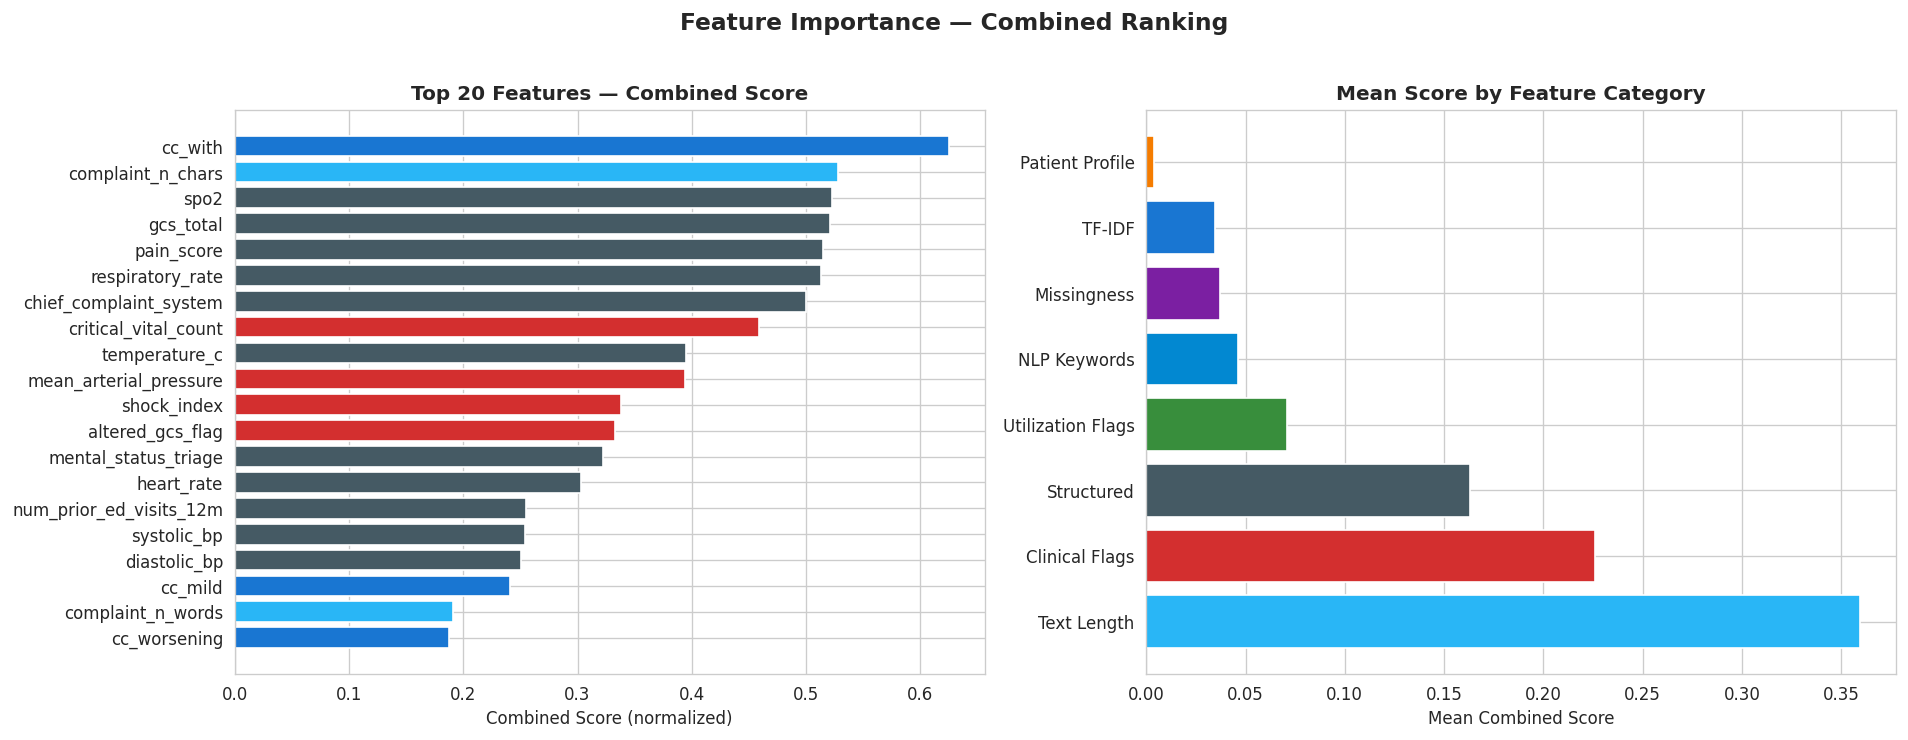

In [53]:
# ============================================================
# G.4 — Feature Categories Analysis
# ============================================================

print("=" * 65)
print("G.4 — FEATURE CATEGORIES ANALYSIS")
print("=" * 65)
print()

# Catégoriser les features
def categorize_feature(feat):
    if feat.startswith('cc_'):
        return 'TF-IDF'
    elif feat.startswith('has_') or feat == 'critical_keyword_count':
        return 'NLP Keywords'
    elif feat.startswith('complaint_'):
        return 'Text Length'
    elif feat in [
            'hypoxemia_flag', 'tachycardia_flag',
            'hypotension_flag', 'fever_flag',
            'altered_gcs_flag', 'severe_pain_flag',
            'critical_vital_count',            # ← déplacé ici
            'mean_arterial_pressure',
            'pulse_pressure', 'shock_index']:
        return 'Clinical Flags'
    elif feat in [
            'elderly', 'very_elderly', 'pediatric',
            'high_comorbidity', 'polypharmacy',
            'obesity']:
        return 'Patient Profile'
    elif feat in [
            'frequent_ed_user', 'prior_admission_flag',
            'high_utilization']:
        return 'Utilization Flags'
    elif '_missing' in feat or feat == 'pain_not_recorded':
        return 'Missingness'
    else:
        return 'Structured'

combined['Category'] = combined.index.map(
    categorize_feature)

# Score moyen par catégorie
cat_scores = combined.groupby(
    'Category')['Combined_Score'].agg(
    ['mean', 'max', 'count']
).sort_values('mean', ascending=False)

print(f"  {'Category':<20} {'Mean':>8} "
      f"{'Max':>8} {'Count':>8}")
print("-" * 50)
for cat, row in cat_scores.iterrows():
    bar = '█' * int(row['mean'] * 20)
    print(f"  {cat:<20} {row['mean']:>8.3f} "
          f"{row['max']:>8.3f} "
          f"{row['count']:>8.0f}  {bar}")

print()

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Top 20 Combined ---
top20 = combined.head(20)
colors_map = {
    'TF-IDF'          : '#1976d2',
    'NLP Keywords'    : '#0288d1',
    'Text Length'     : '#29b6f6',
    'Clinical Flags'  : '#d32f2f',
    'Patient Profile' : '#f57c00',
    'Utilization Flags': '#388e3c',
    'Missingness'     : '#7b1fa2',
    'Structured'      : '#455a64'
}

bar_colors = [
    colors_map.get(
        categorize_feature(f), '#455a64')
    for f in top20.index
]

axes[0].barh(
    top20.index[::-1],
    top20['Combined_Score'].values[::-1],
    color=bar_colors[::-1],
    edgecolor='white'
)
axes[0].set_title('Top 20 Features — Combined Score',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Combined Score (normalized)')

# --- Score moyen par catégorie ---
cat_colors = [
    colors_map.get(c, '#455a64')
    for c in cat_scores.index
]
axes[1].barh(
    cat_scores.index,
    cat_scores['mean'].values,
    color=cat_colors,
    edgecolor='white'
)
axes[1].set_title('Mean Score by Feature Category',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean Combined Score')

plt.suptitle('Feature Importance — Combined Ranking',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### G.5 — Low Importance Features

In [54]:
# ============================================================
# G.5 — Low Importance Features
# ============================================================

print("=" * 65)
print("G.5 — LOW IMPORTANCE FEATURES")
print("=" * 65)
print()

# Seuil
threshold_mi  = mi_df['MI_Score'].quantile(0.10)
threshold_lgb = lgb_df['LGB_Importance'].quantile(0.10)
threshold_lgb = lgb_df['LGB_Importance'].quantile(0.10)

low_mi = set(
    mi_df[mi_df['MI_Score'] < threshold_mi]['Feature']
)
low_lgb = set(
    lgb_df[lgb_df['LGB_Importance'] < threshold_lgb]['Feature']
)

# Features faibles dans les deux
low_both = low_mi.intersection(low_lgb)

print(f"  Threshold MI        : {threshold_mi}")
print(f"  Threshold LGB       : {threshold_lgb:.1f}")
print()
print(f"  Features low in MI  : {len(low_mi)}")
print(f"  Features low in LGB : {len(low_lgb)}")
print(f"  Features low in BOTH: {len(low_both)}")
print()

if len(low_both) > 0:
    print(f"  CANDIDATES FOR REMOVAL :")
    for feat in sorted(low_both):
        cat = categorize_feature(feat)
        print(f"    ⚠️  {feat:<40} [{cat}]")
else:
    print("  ✅ No obvious low-importance features found")

print()
print("  NOTE : These are CANDIDATES only.")
print("  Final decision will be made during modeling.")
print("  LightGBM handles irrelevant features well.")

G.5 — LOW IMPORTANCE FEATURES

  Threshold MI        : 0.0030364813081755317
  Threshold LGB       : 0.0

  Features low in MI  : 38
  Features low in LGB : 0
  Features low in BOTH: 0

  ✅ No obvious low-importance features found

  NOTE : These are CANDIDATES only.
  Final decision will be made during modeling.
  LightGBM handles irrelevant features well.
